# Previsão de Preço Justo — Materiais Recicláveis (Polen)

**Objetivo:** Construir uma referência de preço justo (R$/kg) por grupo de material × estado, com modelos de previsão para VENDAS.

**Pipeline:**
1. Carregar e replicar pipeline de classificação (EDA_polen)
2. Referência estatística (mediana, percentis, IQR)
3. Análise de outliers e qualidade dos dados
4. Feature engineering (ciclicidade mensal, lags, volume)
5. Baselines (mediana, média móvel)
6. Modelos ML (Linear, Ridge, RandomForest, XGBoost, LightGBM)
7. Tabela de preço justo e visualizações finais

In [14]:
%pip install xgboost lightgbm --quiet

Note: you may need to restart the kernel to use updated packages.


In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import warnings
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
sns.set_style("whitegrid")

# Try optional ML libs
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed — skipping XGBRegressor")

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("lightgbm not installed — skipping LGBMRegressor")

print("Imports OK")

Imports OK


In [ ]:
# %% PHASE 1: Advanced Clustering & Price Tier Preparation

def emergency_fix_outros(df):
    """
    Critical fix: Split OUTROS into metal/plastic/paper subgroups.
    Metals (Latin/Alumínio) trade at 8-12 R$/kg vs Plastics at 0.5-2 R$/kg.
    """
    df = df.copy()

    def classify_outros_subtype(row):
        desc = str(row['estoque_product']).upper()
        price = row['unitpricekg_product']

        # High-value metals (price > 4 or keywords)
        if price > 4.0 or any(k in desc for k in ['LATIN', 'ALUMIN', 'LATA', 'COBRE']):
            return 'METAIS_DIVERSOS'

        # Plastic by type (check material first, then description)
        if row['material'] == 'PET' or 'PET' in desc:
            return 'OUTROS_PET'
        if any(x in desc for x in ['PEAD', 'FILME', 'PEBD']):
            return 'OUTROS_PEAD'
        if 'PP' in desc or 'POLIPROPILENO' in desc:
            return 'OUTROS_PP'
        if 'PS' in desc:
            return 'OUTROS_PS'
        if 'PVC' in desc:
            return 'OUTROS_PVC'
        if any(x in desc for x in ['PLAST', 'SUCATA PLAST']):
            return 'OUTROS_PLASTICOS_MISTOS'

        # Low-value materials
        if any(x in desc for x in ['PAPEL', 'CARTON', 'PAPELAO']):
            return 'OUTROS_PAPEIS'
        if any(x in desc for x in ['MADEIR', 'PALLET', 'MACICA']):
            return 'OUTROS_MADEIRA'

        return 'OUTROS_RESIDUAL'

    # Apply only to OUTROS group
    mask = df['material_group'] == 'OUTROS'
    df.loc[mask, 'material_group_refined'] = df.loc[mask].apply(classify_outros_subtype, axis=1)
    df.loc[~mask, 'material_group_refined'] = df.loc[~mask, 'material_group']

    return df

def assign_price_tiers(df, n_tiers=3, method='quantile'):
    """
    Create price tiers within each material_group to separate premium/standard/low-grade.
    Uses 2023-2024 data only to avoid leakage.
    """
    df = df.copy()
    train_data = df[df['year'].isin([2023, 2024])]

    # Calculate product medians from training period
    product_stats = train_data.groupby(['material_group_refined', 'estoque_product'])['unitpricekg_product'].agg([
        'median', 'count'
    ]).reset_index()

    # Only tier products with sufficient observations (n>=5)
    product_stats = product_stats[product_stats['count'] >= 5]

    df['price_tier'] = df['material_group_refined']  # Default

    for (material, state), group in df.groupby(['material_group_refined', 'emitterstateuf']):
        products_in_state = group['estoque_product'].unique()
        stats = product_stats[
            (product_stats['material_group_refined'] == material) &
            (product_stats['estoque_product'].isin(products_in_state))
        ]

        if len(stats) < n_tiers:
            continue  # Too few products, keep original grouping

        if method == 'quantile':
            # Create tiers based on price quantiles
            labels = [f"{material}_TIER{i+1}" for i in range(n_tiers)]
            try:
                tiers = pd.qcut(stats['median'], q=n_tiers, labels=labels, duplicates='drop')
                tier_map = dict(zip(stats['estoque_product'], tiers))

                mask = (df['material_group_refined'] == material) & (df['emitterstateuf'] == state)
                df.loc[mask, 'price_tier'] = df.loc[mask, 'estoque_product'].map(tier_map).fillna(material)
            except ValueError:
                pass  # Edge case: all prices identical

    return df

# Apply fixes
df_price_clean = emergency_fix_outros(df_price_clean)
df_price_clean = assign_price_tiers(df_price_clean, n_tiers=3, method='quantile')

print("Clustering applied:")
print(df_price_clean['material_group_refined'].value_counts())
print("\nPrice tier distribution:")
print(df_price_clean['price_tier'].value_counts())

## 1. Carregar Dados e Replicar Pipeline de Classificação

Replica o mesmo pipeline do EDA: carga CSVs → limpeza → classify_natop → classify_material_group (estoque) → TF-IDF mapping → df_matched.

In [107]:
# === Load CSVs ===
df_invoices = pd.read_csv("products_invoices.csv")
df_estoque = pd.read_csv("consulta_estoque.csv")
print(f"products_invoices: {df_invoices.shape}")
print(f"consulta_estoque:  {df_estoque.shape}")

# === Cleanup (same as EDA) ===
est_drop = ["_fivetran_synced", "_fivetran_deleted", "estoque_minimo", "reservado"]
est_null = df_estoque.columns[df_estoque.isnull().mean() > 0.5].tolist()
df_estoque = df_estoque.drop(columns=list(set(est_drop + est_null)), errors="ignore")

inv_drop = [
    "id_product", "fivetran_deleted_product",
    "id_operatorinvoice", "fivetran_deleted_operatorinvoice",
    "id_subsidiary", "fivetran_deleted_subsidiary", "companyid",
    "status_product", "product_invalidations", "product_nf",
    "licensecetesb", "sefaz_valida",
    "has_invoice_credit", "id_invoicecredit", "createdat_invoicecredit",
    "was_purchased", "purchaseordersids", "purchaseorders_codes",
    "was_compensation", "compensations_ids",
    "createdat_product", "createdat_operatorinvoice", "createdat_subsidiary",
    "danfe", "danfe_materials", "aditional_cpl_operatorinvoice",
    "isblocked_operatorinvoice", "volume_attention", "volume_attention_por_data",
    "invoice_in_offer",
    "emitterlegaldoc", "emitterlegalname", "emitterfantasyname",
    "emitterneighborhood", "emitternumber", "emitterphone",
    "emitterstreet", "emitterzipcode",
    "receiverlegaldoc", "receiverlegalname",
    "receivernumber", "receiverphone", "receiverstreet", "receiverzipcode",
    "status_subsidiary", "phone_subsidiary", "email_subsidiary",
    "address1_subsidiary", "neighbourhood_subsidiary",
    "number_subsidiary", "legalname_subsidiary", "cnpj_subsidiary",
    "zip_subsidiary",
]
inv_null = df_invoices.columns[df_invoices.isnull().mean() > 0.5].tolist()
df_invoices = df_invoices.drop(columns=list(set(inv_drop + inv_null)), errors="ignore")

df_invoices["emittedat_operatorinvoice"] = pd.to_datetime(
    df_invoices["emittedat_operatorinvoice"], errors="coerce"
)
df_invoices["year"] = df_invoices["emittedat_operatorinvoice"].dt.year
df_invoices["month"] = df_invoices["emittedat_operatorinvoice"].dt.month
df_invoices["year_month"] = df_invoices["emittedat_operatorinvoice"].dt.to_period("M")
df_invoices = df_invoices[df_invoices["year"].isin([2023, 2024, 2025])].copy()

print(f"\nAfter cleanup — invoices: {df_invoices.shape}, estoque: {df_estoque.shape}")

/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_34031/2523022002.py:2: DtypeWarning: Columns (87,89,91,92,95) have mixed types. Specify dtype option on import or set low_memory=False.
  df_invoices = pd.read_csv("products_invoices.csv")


products_invoices: (95320, 111)
consulta_estoque:  (66, 17)

After cleanup — invoices: (87943, 33), estoque: (66, 10)


/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_34031/2523022002.py:43: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_invoices["year_month"] = df_invoices["emittedat_operatorinvoice"].dt.to_period("M")


In [108]:
# === NATOP classification + material group pipeline (same as EDA) ===

def classify_natop(natop):
    if pd.isna(natop):
        return "OUTROS"
    s = str(natop).strip().lower()
    is_inter = any(kw in s for kw in [
        "interestadual", "inter estadual", "interstate",
        "fora do estado", "fora estado", "outros estados",
    ])
    if is_inter:
        if any(kw in s for kw in ["venda", "vda", "saida", "saída", "remessa", "sucata"]):
            return "VENDA INTERESTADUAL"
        if any(kw in s for kw in ["compra", "cpa", "entrada", "aquisicao", "aquisição"]):
            return "COMPRA INTERESTADUAL"
        return "OUTROS"
    if any(kw in s for kw in ["venda", "vda", "vnd"]):
        return "VENDA"
    if re.search(r"\bsaida\b|\bsaída\b", s) and not any(kw in s for kw in ["devolucao", "devolução", "retorno"]):
        return "VENDA"
    if any(kw in s for kw in ["compra", "cpa"]):
        return "COMPRA"
    if re.search(r"\bentrada\b", s) and not any(kw in s for kw in ["devolucao", "devolução", "retorno"]):
        return "COMPRA"
    if any(kw in s for kw in ["aquisicao", "aquisição"]):
        return "COMPRA"
    return "OUTROS"

def classify_material_group(text):
    if pd.isna(text):
        return "OUTROS"
    s = str(text).strip().upper()
    if "PEAD" in s:                              return "PEAD"
    if "PET" in s:                               return "PET"
    if "BOPP" in s or "RAFIA" in s:              return "BOPP/RAFIA"
    if "PP" in s:                                return "PP"
    if "PS" in s:                                return "PS"
    if "PVC" in s:                               return "PVC"
    if "PE " in s or "FILME" in s or s.startswith("PE"): return "PE/FILME"
    return "OUTROS"

def normalize_text(s):
    if pd.isna(s):
        return ""
    s = str(s).strip().upper()
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return " ".join(s.split())

# ── Synonym / alias expansion (mirrors EDA) ─────────────────────────────
SYNONYMS = {
    "LATAS DE ALUMINIO": "LATINHAS", "LATA DE ALUMINIO": "LATINHAS",
    "LATINHAS DE ALUMINIO": "LATINHAS", "LATINHA DE ALUMINIO": "LATINHAS",
    "LATA ALUMINIO": "LATINHAS", "LATAS ALUMINIO": "LATINHAS",
    "ALUMINIO LATA": "LATINHAS", "LATINHA": "LATINHAS",
    "SACOLAS": "SACOLINHA", "SACOLA": "SACOLINHA", "SACOLINHAS": "SACOLINHA",
    "FILME PEBD": "FILME", "FILME PE": "FILME", "PEBD": "PE",
    "RAFFIA": "RAFIA", "BIG BAGS": "RAFIA", "BIG BAG": "RAFIA", "BIGBAG": "RAFIA",
    "COPOS": "COPINHO", "COPO": "COPINHO",
    "POTES MARGARINA": "MARGARINA", "POTE MARGARINA": "MARGARINA",
    "POTE DE MARGARINA": "MARGARINA",
    "BALDES": "BALDE BACIA", "BALDE": "BALDE BACIA",
    "BACIAS": "BALDE BACIA", "BACIA": "BALDE BACIA",
    "TAMPAS": "TAMPINHA", "TAMPA": "TAMPINHA", "TAMPINHAS": "TAMPINHA",
    "PRE-FORMA": "PREFORMA", "PRE FORMA": "PREFORMA",
    "BANDEJAS": "BANDEJA",
    "APARAS DE": "SUCATA DE", "APARA DE": "SUCATA DE",
    "APARAS": "SUCATA", "APARA": "SUCATA",
    "POS CONSUMO": "", "POS-CONSUMO": "", "PRE CONSUMO": "", "PRE-CONSUMO": "",
    "RECICLADO": "", "RECICLADA": "", "TRITURADO": "", "TRITURADA": "",
    "MOIDO": "", "MOIDA": "",
}
_SORTED_SYNS = sorted(SYNONYMS.items(), key=lambda x: -len(x[0]))

def expand_synonyms(text):
    for old, new in _SORTED_SYNS:
        text = re.sub(r'\b' + re.escape(old) + r'\b', new, text)
    return " ".join(text.split())

GROUP_COLORS = {
    "PET": "#1f77b4", "PP": "#ff7f0e", "PEAD": "#2ca02c",
    "PS": "#d62728", "PE/FILME": "#9467bd", "PVC": "#8c564b",
    "BOPP/RAFIA": "#e377c2", "OUTROS": "#7f7f7f",
}

# --- Classify ---
df_invoices["natop_category"] = df_invoices["natop_operatorinvoice"].apply(classify_natop)
df_estoque["material_group"] = df_estoque["c_descricao"].apply(classify_material_group)

mask = (
    df_invoices["material"].notna()
    & (df_invoices["material"].str.strip() != "")
    & (df_invoices["material"].str.strip().str.lower() != "unknown")
    & df_invoices["description_product"].notna()
    & (df_invoices["description_product"].str.strip() != "")
    & (df_invoices["natop_category"] != "OUTROS")
)
df_clean = df_invoices[mask].copy()
print(f"df_clean: {len(df_clean)} rows")

# --- TF-IDF matching with synonym expansion + hybrid scoring ---
estoque_products = sorted(set(
    p for p in df_estoque["c_descricao"].dropna().apply(normalize_text).unique() if p
))
estoque_expanded = [expand_synonyms(p) for p in estoque_products]

estoque_to_group = {}
for _, row in df_estoque.dropna(subset=["c_descricao"]).iterrows():
    key = normalize_text(row["c_descricao"])
    if key:
        estoque_to_group[key] = row["material_group"]

unique_descs = sorted(set(
    d for d in df_clean["description_product"].dropna().apply(normalize_text).unique() if d
))
descs_expanded = [expand_synonyms(d) for d in unique_descs]

# Hybrid: char n-gram + word-level TF-IDF
all_expanded = estoque_expanded + descs_expanded
n_est = len(estoque_expanded)

vec_char = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4))
tfidf_char = vec_char.fit_transform(all_expanded)
sim_char = cosine_similarity(tfidf_char[n_est:], tfidf_char[:n_est])

vec_word = TfidfVectorizer(analyzer="word", ngram_range=(1, 2))
tfidf_word = vec_word.fit_transform(all_expanded)
sim_word = cosine_similarity(tfidf_word[n_est:], tfidf_word[:n_est])

sim_matrix = 0.5 * sim_char + 0.5 * sim_word

THRESHOLD = 0.25
match_map = {}
for i, desc in enumerate(unique_descs):
    best_idx = sim_matrix[i].argmax()
    best_score = sim_matrix[i, best_idx]
    if best_score >= THRESHOLD:
        match_map[desc] = (estoque_products[best_idx], round(best_score, 3))
    else:
        match_map[desc] = ("SEM CORRESPONDENCIA", round(best_score, 3))

df_clean["desc_normalized"] = df_clean["description_product"].apply(normalize_text)
df_clean["estoque_product"] = df_clean["desc_normalized"].map(
    lambda d: match_map.get(d, ("SEM CORRESPONDENCIA", 0))[0]
)
df_clean["match_score"] = df_clean["desc_normalized"].map(
    lambda d: match_map.get(d, ("SEM CORRESPONDENCIA", 0))[1]
)
df_clean["material_group"] = df_clean["desc_normalized"].map(
    lambda d: estoque_to_group.get(match_map.get(d, ("", 0))[0], None)
)
mask_no_group = df_clean["material_group"].isna()
df_clean.loc[mask_no_group, "material_group"] = (
    df_clean.loc[mask_no_group, "material"].apply(classify_material_group)
)

df_matched = df_clean[df_clean["match_score"] > 0.6].copy()

venda_cats = ["VENDA", "VENDA INTERESTADUAL"]
groups_sorted = [g for g in GROUP_COLORS if g in df_matched["material_group"].unique()]

print(f"df_matched: {len(df_matched)} rows ({round(len(df_matched)/len(df_clean)*100,1)}%)")
print(f"Groups: {groups_sorted}")
display(df_matched["material_group"].value_counts().sort_index())

df_clean: 85691 rows
df_matched: 21269 rows (24.8%)
Groups: ['PET', 'PP', 'PEAD', 'PS', 'PE/FILME', 'PVC', 'BOPP/RAFIA', 'OUTROS']


material_group
BOPP/RAFIA     465
OUTROS        5429
PE/FILME       392
PEAD          3894
PET           6678
PP            3692
PS             247
PVC            472
Name: count, dtype: int64

## 2. Referência Estatística de Preço (R$/kg)

Antes de qualquer modelo, vamos construir uma **tabela de preço-referência** baseada em estatísticas descritivas: mediana, média, percentis 25/75, e IQR. Apenas VENDAS.

Rows with valid price > 0: 21185

  VENDAS — Preço-Referência R$/kg


,material_group,state,n,mean,median,std,Q1,Q3,IQR,cv_%
5,BOPP/RAFIA,PR,185,0.300,0.30,0.101,0.200,0.400,0.200,33.7
8,BOPP/RAFIA,SC,136,0.610,0.65,0.080,0.500,0.650,0.150,13.0
9,BOPP/RAFIA,SP,68,0.249,0.30,0.161,0.138,0.300,0.162,64.8
3,BOPP/RAFIA,MG,23,13.376,0.20,62.485,0.200,0.225,0.025,467.1
7,BOPP/RAFIA,RS,17,0.213,0.15,0.206,0.100,0.200,0.100,96.7
...,...,...,...,...,...,...,...,...,...,...
106,PVC,ES,2,0.500,0.50,0.000,0.500,0.500,0.000,0.0
113,PVC,PI,2,0.300,0.30,0.000,0.300,0.300,0.000,0.0
116,PVC,RN,2,5.000,5.00,2.828,4.000,6.000,2.000,56.6
110,PVC,MS,1,0.100,0.10,NaN,0.100,0.100,0.000,NaN


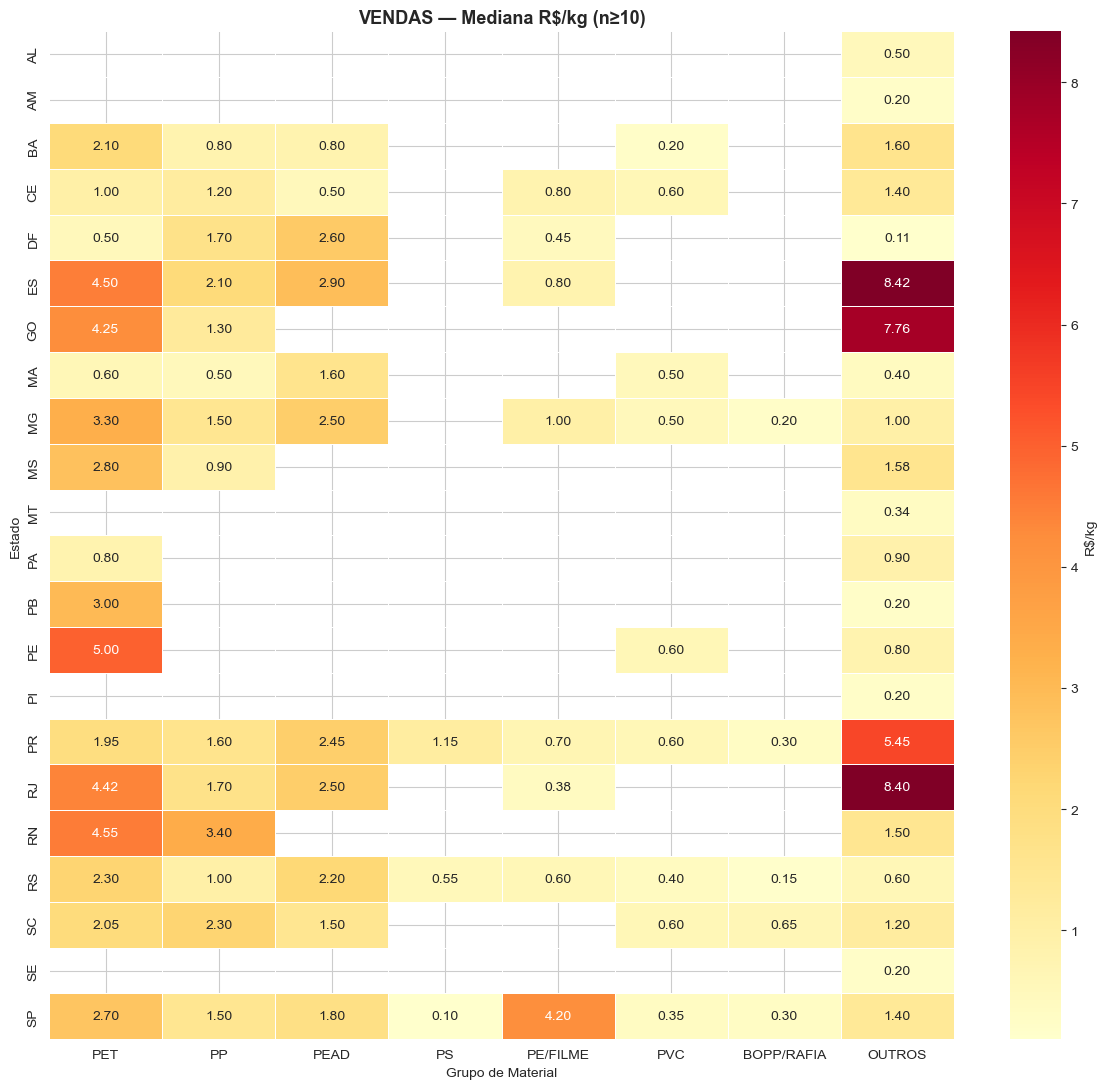

In [109]:
# === Statistical price reference: median, mean, percentiles ===

price_col = "unitpricekg_product"
df_price = df_matched.dropna(subset=[price_col]).copy()
df_price = df_price[df_price[price_col] > 0]
print(f"Rows with valid price > 0: {len(df_price)}")

def price_reference_table(df_subset, label):
    """Compute price stats per material_group × state."""
    if len(df_subset) == 0:
        print(f"\n{label}: sem dados")
        return None
    ref = (
        df_subset.groupby(["material_group", "emitterstateuf"])[price_col]
        .agg(["count", "mean", "median", "std",
              lambda x: x.quantile(0.25),
              lambda x: x.quantile(0.75)])
        .reset_index()
    )
    ref.columns = ["material_group", "state", "n", "mean", "median", "std", "Q1", "Q3"]
    ref["IQR"] = ref["Q3"] - ref["Q1"]
    ref["cv_%"] = (ref["std"] / ref["mean"] * 100).round(1)
    ref = ref.sort_values(["material_group", "n"], ascending=[True, False])

    print(f"\n{'='*60}")
    print(f"  {label} — Preço-Referência R$/kg")
    print(f"{'='*60}")
    display(ref.round(3))

    # Heatmap: median price
    ref_sig = ref[ref["n"] >= 10]
    pivot = ref_sig.pivot(index="state", columns="material_group", values="median")
    pivot = pivot[[g for g in groups_sorted if g in pivot.columns]]
    if not pivot.empty:
        fig, ax = plt.subplots(figsize=(12, max(4, len(pivot) * 0.5)))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
                    linewidths=0.5, cbar_kws={"label": "R$/kg"})
        ax.set_title(f"{label} — Mediana R$/kg (n≥10)", fontsize=13, fontweight="bold")
        ax.set_ylabel("Estado")
        ax.set_xlabel("Grupo de Material")
        plt.tight_layout()
        plt.show()

    return ref

ref_vendas = price_reference_table(
    df_price[df_price["natop_category"].isin(venda_cats)], "VENDAS")

## 3. Análise de Outliers e Qualidade dos Dados

Identificação e remoção de outliers extremos via IQR (1.5×). Avaliação de cobertura temporal por grupo × estado.

In [110]:
# === Outlier analysis + removal (IQR 1.5x per group×state) ===

def remove_outliers_iqr(df, col, groupby_cols, k=1.5):
    """Remove outliers using IQR method within each group."""
    records = []
    clean_dfs = []
    for name, grp in df.groupby(groupby_cols):
        q1 = grp[col].quantile(0.25)
        q3 = grp[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        mask = (grp[col] >= lower) & (grp[col] <= upper)
        n_before = len(grp)
        n_after = mask.sum()
        records.append({
            "group": name if isinstance(name, str) else " | ".join(str(x) for x in name),
            "n_before": n_before, "n_after": n_after,
            "removed": n_before - n_after,
            "removed_%": round((n_before - n_after) / n_before * 100, 1) if n_before > 0 else 0,
            "lower": round(lower, 3), "upper": round(upper, 3),
        })
        clean_dfs.append(grp[mask])

    df_clean_out = pd.concat(clean_dfs, ignore_index=True)
    summary = pd.DataFrame(records)
    return df_clean_out, summary

df_price_clean, outlier_summary = remove_outliers_iqr(
    df_price, price_col, ["material_group", "emitterstateuf"]
)

print(f"Before outlier removal: {len(df_price)} rows")
print(f"After outlier removal:  {len(df_price_clean)} rows")
print(f"Removed: {len(df_price) - len(df_price_clean)} ({round((len(df_price)-len(df_price_clean))/len(df_price)*100,1)}%)\n")

# Show groups with significant removal
sig = outlier_summary[outlier_summary["removed_%"] > 5].sort_values("removed_%", ascending=False)
if len(sig) > 0:
    print("Groups with >5% outliers removed:")
    display(sig)
else:
    print("No group had >5% outlier removal.")

# --- Coverage assessment ---
ALL_MONTHS = pd.period_range("2023-01", "2025-12", freq="M")
TOTAL_MONTHS = len(ALL_MONTHS)

coverage = (
    df_price_clean.groupby(["material_group", "emitterstateuf"])
    .agg(
        n_rows=(price_col, "count"),
        n_months=("year_month", "nunique"),
        n_products=("estoque_product", "nunique"),
    ).reset_index()
)
coverage["coverage_%"] = (coverage["n_months"] / TOTAL_MONTHS * 100).round(1)
coverage["rows_per_month"] = (coverage["n_rows"] / coverage["n_months"]).round(1)

# Quality tiers
def quality_tier(row):
    if row["n_months"] >= 24 and row["n_rows"] >= 100:
        return "A (excellent)"
    elif row["n_months"] >= 12 and row["n_rows"] >= 30:
        return "B (good)"
    elif row["n_months"] >= 6 and row["n_rows"] >= 10:
        return "C (fair)"
    else:
        return "D (insufficient)"

coverage["quality"] = coverage.apply(quality_tier, axis=1)

print(f"\n=== Data Quality Tiers ===")
display(coverage["quality"].value_counts().sort_index())
print()
display(coverage.sort_values(["quality", "material_group", "n_rows"], ascending=[True, True, False]))

Before outlier removal: 21185 rows
After outlier removal:  20454 rows
Removed: 731 (3.5%)

Groups with >5% outliers removed:


,group,n_before,n_after,removed,removed_%,lower,upper
87,PP | MA,46,29,17,37.0,0.125,0.725
22,OUTROS | MT,209,144,65,31.1,0.250,0.490
96,PP | SC,20,14,6,30.0,1.475,3.275
48,PEAD | BA,39,28,11,28.2,0.800,0.800
3,BOPP/RAFIA | MG,23,17,6,26.1,0.163,0.262
2,BOPP/RAFIA | GO,4,3,1,25.0,0.063,0.362
62,PET | AM,8,6,2,25.0,2.188,2.688
35,OUTROS | TO,4,3,1,25.0,0.121,0.431
99,PS | MG,9,7,2,22.2,0.500,1.300
108,PVC | MA,19,15,4,21.1,0.500,0.500



=== Data Quality Tiers ===


quality
A (excellent)       38
B (good)            26
C (fair)            22
D (insufficient)    35
Name: count, dtype: int64

,material_group,emitterstateuf,n_rows,n_months,n_products,coverage_%,rows_per_month,quality
5,BOPP/RAFIA,PR,185,36,2,100.0,5.1,A (excellent)
8,BOPP/RAFIA,SC,136,32,1,88.9,4.2,A (excellent)
20,OUTROS,MG,829,36,4,100.0,23.0,A (excellent)
34,OUTROS,SP,640,36,4,100.0,17.8,A (excellent)
17,OUTROS,ES,500,36,2,100.0,13.9,A (excellent)
...,...,...,...,...,...,...,...,...
106,PVC,ES,2,2,1,5.6,1.0,D (insufficient)
113,PVC,PI,2,2,1,5.6,1.0,D (insufficient)
116,PVC,RN,2,1,1,2.8,2.0,D (insufficient)
110,PVC,MS,1,1,1,2.8,1.0,D (insufficient)


## 3b. Clusterização Avançada de Preços

**Problema:** O grupo OUTROS mistura metais (8-12 R$/kg) com plásticos (0.5-2 R$/kg), gerando alta variância.

**Solução:**
1. **Emergency fix OUTROS:** Separa metais, subtipos plásticos, papéis, madeira
2. **Price tiers:** Cria faixas de preço (quantis) dentro de cada grupo refinado
3. **Cluster optimizer:** Testa 4 estratégias de agrupamento e seleciona a de menor MAE

In [128]:
# %% PHASE 1: Advanced Clustering & Price Tier Preparation

def emergency_fix_outros(df):
    """
    Critical fix: Split OUTROS into metal/plastic/paper subgroups.
    Metals (Latin/Alumínio) trade at 8-12 R$/kg vs Plastics at 0.5-2 R$/kg.
    """
    df = df.copy()

    def classify_outros_subtype(row):
        desc = str(row['estoque_product']).upper()
        price = row[price_col]

        # High-value metals (price > 4 or keywords)
        if price > 4.0 or any(k in desc for k in ['LATIN', 'ALUMIN', 'LATA', 'COBRE']):
            return 'METAIS_DIVERSOS'

        # Plastic by type (check material_group first, then description)
        mat = str(row.get('material', '')).upper()
        if mat == 'PET' or 'PET' in desc:
            return 'OUTROS_PET'
        if any(x in desc for x in ['PEAD', 'FILME', 'PEBD']):
            return 'OUTROS_PEAD'
        if 'PP' in desc or 'POLIPROPILENO' in desc:
            return 'OUTROS_PP'
        if 'PS' in desc:
            return 'OUTROS_PS'
        if 'PVC' in desc:
            return 'OUTROS_PVC'
        if any(x in desc for x in ['PLAST', 'SUCATA PLAST']):
            return 'OUTROS_PLASTICOS_MISTOS'

        # Low-value materials
        if any(x in desc for x in ['PAPEL', 'CARTON', 'PAPELAO']):
            return 'OUTROS_PAPEIS'
        if any(x in desc for x in ['MADEIR', 'PALLET', 'MACICA']):
            return 'OUTROS_MADEIRA'

        return 'OUTROS_RESIDUAL'

    # Apply only to OUTROS group
    mask = df['material_group'] == 'OUTROS'
    df['material_group_refined'] = df['material_group']
    df.loc[mask, 'material_group_refined'] = df.loc[mask].apply(classify_outros_subtype, axis=1)

    return df


def assign_price_tiers(df, n_tiers=3, method='quantile'):
    """
    Create price tiers within each material_group to separate premium/standard/low-grade.
    Uses 2023-2024 data only to avoid leakage.
    """
    df = df.copy()
    train_data = df[df['year'].isin([2023, 2024])]

    # Calculate product medians from training period
    product_stats = train_data.groupby(
        ['material_group_refined', 'estoque_product']
    )[price_col].agg(['median', 'count']).reset_index()

    # Only tier products with sufficient observations (n>=5)
    product_stats = product_stats[product_stats['count'] >= 5]

    df['price_tier'] = df['material_group_refined']  # Default

    for material, mat_stats in product_stats.groupby('material_group_refined'):
        if len(mat_stats) < n_tiers:
            continue

        labels = [f"{material}_TIER{i+1}" for i in range(n_tiers)]
        try:
            tiers = pd.qcut(mat_stats['median'], q=n_tiers, labels=labels, duplicates='drop')
            tier_map = dict(zip(mat_stats['estoque_product'], tiers))

            mask = df['material_group_refined'] == material
            mapped = df.loc[mask, 'estoque_product'].map(tier_map)
            df.loc[mask, 'price_tier'] = mapped.fillna(material)
        except ValueError:
            pass  # Edge case: all prices identical

    return df


# Apply fixes
df_price_clean = emergency_fix_outros(df_price_clean)
df_price_clean = assign_price_tiers(df_price_clean, n_tiers=3, method='quantile')

print("=== OUTROS Refinement ===")
outros_before = (df_price_clean['material_group'] == 'OUTROS').sum()
print(f"OUTROS rows total: {outros_before}")
print(f"\nRefined breakdown:")
refined_outros = df_price_clean[df_price_clean['material_group'] == 'OUTROS']['material_group_refined'].value_counts()
print(refined_outros.to_string())

# CV comparison: OUTROS original vs refined sub-groups
outros_orig_cv = df_price_clean[df_price_clean['material_group'] == 'OUTROS'][price_col].std() / \
                 df_price_clean[df_price_clean['material_group'] == 'OUTROS'][price_col].mean()
print(f"\nOriginal OUTROS CV: {outros_orig_cv:.3f}")
print("\nRefined sub-group CVs:")
for grp, sub in df_price_clean[df_price_clean['material_group'] == 'OUTROS'].groupby('material_group_refined'):
    cv = sub[price_col].std() / sub[price_col].mean() if sub[price_col].mean() > 0 else 0
    print(f"  {grp}: CV={cv:.3f} (n={len(sub)}, mean={sub[price_col].mean():.2f} R$/kg)")

print(f"\n=== Full Clustering Distribution ===")
print(f"\nmaterial_group_refined:")
print(df_price_clean['material_group_refined'].value_counts().to_string())
print(f"\nprice_tier (top 20):")
print(df_price_clean['price_tier'].value_counts().head(20).to_string())

=== OUTROS Refinement ===
OUTROS rows total: 4862

Refined breakdown:
material_group_refined
OUTROS_PLASTICOS_MISTOS    3126
METAIS_DIVERSOS            1631
OUTROS_RESIDUAL             105

Original OUTROS CV: 1.139

Refined sub-group CVs:
  METAIS_DIVERSOS: CV=0.321 (n=1631, mean=8.80 R$/kg)
  OUTROS_PLASTICOS_MISTOS: CV=0.942 (n=3126, mean=0.98 R$/kg)
  OUTROS_RESIDUAL: CV=0.710 (n=105, mean=1.16 R$/kg)

=== Full Clustering Distribution ===

material_group_refined:
material_group_refined
PET                        6520
PEAD                       3695
PP                         3536
OUTROS_PLASTICOS_MISTOS    3126
METAIS_DIVERSOS            1631
PVC                         459
BOPP/RAFIA                  432
PE/FILME                    366
PS                          208
OUTROS_RESIDUAL             105

price_tier (top 20):
price_tier
PET_TIER3                  3819
OUTROS_PLASTICOS_MISTOS    3126
PP_TIER3                   1870
PEAD_TIER2                 1826
METAIS_DIVERSOS         

## 4. Feature Engineering — Dual-Target Aggregation

Construção de features para os modelos com **3 estratégias de clustering** testadas em paralelo:
- **material_group:** 8 categorias originais (PET, PP, PEAD, etc.)
- **material_group_refined:** OUTROS separado em subgrupos (METAIS, PET, PEAD, PP, etc.)
- **price_tier:** Faixas de preço (quantis) dentro de cada grupo refinado

Features incluídas:
- Ciclicidade mensal: `month_sin`, `month_cos`
- Lags: mediana do preço nos últimos 3 e 6 meses
- Volume proxy: quantidade de transações no mês
- **Dólar (PTAX):** média mensal USD/BRL
- **IPCA:** variação mensal + índice acumulado
- **Sazonalidade regional:** índice sazonal por cluster × estado × mês
- **Heterogeneidade:** n_products, price_spread, product_concentration

Targets:
- `price_median`, `price_mean`, `price_fair` (mid-quartile robusto)

In [129]:
# === Feature engineering: monthly aggregation + lag features ===
# %% PHASE 2: Dual-Target Monthly Aggregation

# Filter to VENDAS only
df_price_clean = df_price_clean[df_price_clean["natop_category"].isin(venda_cats)].copy()
df_price_clean["side"] = "VENDAS"

# --- Try different clustering keys ---
CLUSTER_KEYS = ['material_group', 'material_group_refined', 'price_tier']
monthly_datasets = {}

for cluster_key in CLUSTER_KEYS:
    m = (
        df_price_clean.groupby([cluster_key, "emitterstateuf", "side", "year", "month"])
        .agg(
            price_median=(price_col, "median"),
            price_mean=(price_col, "mean"),
            price_q25=(price_col, lambda x: x.quantile(0.25)),
            price_q75=(price_col, lambda x: x.quantile(0.75)),
            price_std=(price_col, "std"),
            n_transactions=(price_col, "count"),
        ).reset_index()
    )
    m["price_std"] = m["price_std"].fillna(0)

    # Robust fair price: if mean/median diverge >20%, use median; else mid-quartile
    m["price_fair"] = m.apply(
        lambda row: row["price_median"]
        if row["price_median"] == 0 or abs(row["price_mean"] - row["price_median"]) / row["price_median"] > 0.2
        else (row["price_q25"] + row["price_q75"]) / 2,
        axis=1,
    )
    m["cv"] = np.where(m["price_mean"] > 0, m["price_std"] / m["price_mean"], 0)

    monthly_datasets[cluster_key] = m
    print(f"{cluster_key}: {len(m)} rows, avg CV: {m['cv'].mean():.3f}, groups: {m[cluster_key].nunique()}")

# Start with material_group as default (will be overridden by optimizer)
best_cluster_col = "material_group"
monthly = monthly_datasets[best_cluster_col].copy()

# Cyclical month encoding
monthly["month_sin"] = np.sin(2 * np.pi * monthly["month"] / 12)
monthly["month_cos"] = np.cos(2 * np.pi * monthly["month"] / 12)

# Sort for lag computation
monthly = monthly.sort_values([best_cluster_col, "emitterstateuf", "side", "year", "month"]).reset_index(drop=True)

# Date column
monthly["date"] = pd.to_datetime(monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2) + "-01")

# Lag features: 3-month and 6-month rolling median of price_median
lag_dfs = []
for (grp, state, side), sub in monthly.groupby([best_cluster_col, "emitterstateuf", "side"]):
    sub = sub.sort_values("date").copy()
    sub["lag_3m"] = sub["price_median"].shift(1).rolling(3, min_periods=1).median()
    sub["lag_6m"] = sub["price_median"].shift(1).rolling(6, min_periods=1).median()
    sub["vol_lag_3m"] = sub["n_transactions"].shift(1).rolling(3, min_periods=1).mean()
    lag_dfs.append(sub)

monthly = pd.concat(lag_dfs, ignore_index=True)

# Drop rows without lag (first months of each series)
monthly_feat = monthly.dropna(subset=["lag_3m"]).copy()

print(f"\nMonthly aggregated rows (default {best_cluster_col}): {len(monthly)}")
print(f"With lag features: {len(monthly_feat)}")
print(f"\nTargets available: price_median, price_mean, price_fair")
print(f"Feature columns: {list(monthly_feat.columns)}")
display(monthly_feat.head(10))

material_group: 2069 rows, avg CV: 0.307, groups: 8
material_group_refined: 2291 rows, avg CV: 0.266, groups: 10
price_tier: 3246 rows, avg CV: 0.214, groups: 24

Monthly aggregated rows (default material_group): 2069
With lag features: 1948

Targets available: price_median, price_mean, price_fair
Feature columns: ['material_group', 'emitterstateuf', 'side', 'year', 'month', 'price_median', 'price_mean', 'price_q25', 'price_q75', 'price_std', 'n_transactions', 'price_fair', 'cv', 'month_sin', 'month_cos', 'date', 'lag_3m', 'lag_6m', 'vol_lag_3m']


,material_group,emitterstateuf,side,year,month,price_median,price_mean,price_q25,price_q75,price_std,n_transactions,price_fair,cv,month_sin,month_cos,date,lag_3m,lag_6m,vol_lag_3m
1,BOPP/RAFIA,CE,VENDAS,2024,8,1.150,1.150,1.1500,1.1500,0.000000,1,1.150,0.000000,-0.866025,-5.000000e-01,2024-08-01,0.0800,0.0800,2.000000
3,BOPP/RAFIA,ES,VENDAS,2025,3,0.461,0.461,0.4610,0.4610,0.000000,1,0.461,0.000000,1.000000,6.123234e-17,2025-03-01,0.2000,0.2000,1.000000
4,BOPP/RAFIA,ES,VENDAS,2025,8,0.450,0.450,0.4500,0.4500,0.000000,1,0.450,0.000000,-0.866025,-5.000000e-01,2025-08-01,0.3305,0.3305,1.000000
6,BOPP/RAFIA,GO,VENDAS,2024,2,0.200,0.200,0.2000,0.2000,0.000000,1,0.200,0.000000,0.866025,5.000000e-01,2024-02-01,0.2000,0.2000,1.000000
7,BOPP/RAFIA,GO,VENDAS,2025,1,0.100,0.100,0.1000,0.1000,0.000000,1,0.100,0.000000,0.500000,8.660254e-01,2025-01-01,0.2000,0.2000,1.000000
9,BOPP/RAFIA,MG,VENDAS,2024,2,0.200,0.200,0.2000,0.2000,0.000000,1,0.200,0.000000,0.866025,5.000000e-01,2024-02-01,0.2000,0.2000,1.000000
10,BOPP/RAFIA,MG,VENDAS,2024,3,0.200,0.200,0.2000,0.2000,0.000000,1,0.200,0.000000,1.000000,6.123234e-17,2024-03-01,0.2000,0.2000,1.000000
11,BOPP/RAFIA,MG,VENDAS,2024,4,0.200,0.200,0.2000,0.2000,0.000000,1,0.200,0.000000,0.866025,-5.000000e-01,2024-04-01,0.2000,0.2000,1.000000
12,BOPP/RAFIA,MG,VENDAS,2024,11,0.225,0.225,0.2125,0.2375,0.035355,2,0.225,0.157135,-0.500000,8.660254e-01,2024-11-01,0.2000,0.2000,1.000000
13,BOPP/RAFIA,MG,VENDAS,2025,1,0.200,0.200,0.2000,0.2000,0.000000,1,0.200,0.000000,0.500000,8.660254e-01,2025-01-01,0.2000,0.2000,1.333333


In [130]:
# %% PHASE 3: Iterative Cluster Optimization Framework

class ClusterOptimizer:
    """
    Tests different clustering strategies and selects optimal based on CV and prediction error.
    """

    def __init__(self, df_clean, price_col):
        self.df = df_clean.copy()
        self.price_col = price_col
        self.results = []

    def evaluate_cluster_quality(self, cluster_col, min_obs=20):
        """
        Evaluate clustering by:
        1. Average CV within clusters (lower is better)
        2. Predictability (simplified MAE using last-3-month baseline)
        3. Coverage (how many clusters have sufficient data)
        """
        stats = []

        train = self.df[self.df['year'].isin([2023, 2024])]
        test = self.df[self.df['year'] == 2025]

        for cluster, group in train.groupby([cluster_col, 'emitterstateuf']):
            cluster_id, state = cluster

            if len(group) < min_obs:
                continue

            cv = group[self.price_col].std() / group[self.price_col].mean()

            # Simple baseline: last 3 months median
            last_3m = group.sort_values(['year', 'month']).tail(3)[self.price_col].median()

            test_group = test[(test[cluster_col] == cluster_id) & (test['emitterstateuf'] == state)]
            if len(test_group) == 0:
                continue

            mae = np.abs(test_group[self.price_col] - last_3m).mean()

            stats.append({
                'cluster_id': cluster_id,
                'state': state,
                'cv': cv,
                'mae': mae,
                'n_train': len(group),
                'n_test': len(test_group),
                'price_mean': group[self.price_col].mean()
            })

        if not stats:
            return None

        df_stats = pd.DataFrame(stats)

        weighted_cv = np.average(df_stats['cv'], weights=df_stats['n_train'])
        weighted_mae = np.average(df_stats['mae'], weights=df_stats['n_test'])

        return {
            'cluster_col': cluster_col,
            'n_clusters': self.df[cluster_col].nunique(),
            'n_valid_series': len(df_stats),
            'coverage_pct': round(
                len(df_stats) / max(1, self.df[cluster_col].nunique() * self.df['emitterstateuf'].nunique()) * 100, 1
            ),
            'avg_cv': round(df_stats['cv'].mean(), 4),
            'weighted_cv': round(weighted_cv, 4),
            'avg_mae': round(df_stats['mae'].mean(), 4),
            'weighted_mae': round(weighted_mae, 4),
            'high_variance_clusters': int((df_stats['cv'] > 0.5).sum()),
        }

    def optimize(self):
        """Test all clustering strategies"""
        strategies = {
            'original_material': 'material_group',
            'refined_outros': 'material_group_refined',
            'price_tiers_3': 'price_tier',
        }

        print("=" * 55)
        print("  CLUSTER OPTIMIZATION ITERATION")
        print("=" * 55)

        for name, col in strategies.items():
            print(f"\nTesting {name} ({col})...")
            result = self.evaluate_cluster_quality(col)

            if result:
                result['strategy'] = name
                self.results.append(result)
                print(f"  Weighted CV:  {result['weighted_cv']:.4f}")
                print(f"  Weighted MAE: {result['weighted_mae']:.4f}")
                print(f"  Valid series: {result['n_valid_series']}")
                print(f"  High-variance clusters (CV>0.5): {result['high_variance_clusters']}")

        self.results_df = pd.DataFrame(self.results).sort_values(
            ['weighted_mae', 'weighted_cv']
        )

        print(f"\n{'='*55}")
        print("  OPTIMIZATION RESULTS")
        print(f"{'='*55}")
        display(self.results_df[['strategy', 'cluster_col', 'weighted_mae', 'weighted_cv',
                                  'n_valid_series', 'high_variance_clusters', 'n_clusters']])

        best = self.results_df.iloc[0]
        print(f"\n>>> Best strategy: {best['strategy']} (MAE: {best['weighted_mae']:.4f}, CV: {best['weighted_cv']:.4f})")

        return best['strategy'], best['cluster_col']


# Run optimization
optimizer = ClusterOptimizer(df_price_clean, price_col)
best_strategy, best_cluster_col = optimizer.optimize()
print(f"\nUsing '{best_cluster_col}' for final model training")

# --- Rebuild monthly with best cluster key ---
monthly = monthly_datasets[best_cluster_col].copy()

# Re-compute cyclical + lags for best cluster
monthly["month_sin"] = np.sin(2 * np.pi * monthly["month"] / 12)
monthly["month_cos"] = np.cos(2 * np.pi * monthly["month"] / 12)
monthly = monthly.sort_values([best_cluster_col, "emitterstateuf", "side", "year", "month"]).reset_index(drop=True)
monthly["date"] = pd.to_datetime(monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2) + "-01")

lag_dfs = []
for (grp, state, side), sub in monthly.groupby([best_cluster_col, "emitterstateuf", "side"]):
    sub = sub.sort_values("date").copy()
    sub["lag_3m"] = sub["price_median"].shift(1).rolling(3, min_periods=1).median()
    sub["lag_6m"] = sub["price_median"].shift(1).rolling(6, min_periods=1).median()
    sub["vol_lag_3m"] = sub["n_transactions"].shift(1).rolling(3, min_periods=1).mean()
    lag_dfs.append(sub)
monthly = pd.concat(lag_dfs, ignore_index=True)
monthly_feat = monthly.dropna(subset=["lag_3m"]).copy()

print(f"\nRebuilt monthly_feat with {best_cluster_col}: {len(monthly_feat)} rows")

  CLUSTER OPTIMIZATION ITERATION

Testing original_material (material_group)...
  Weighted CV:  0.5459
  Weighted MAE: 1.5809
  Valid series: 64
  High-variance clusters (CV>0.5): 28

Testing refined_outros (material_group_refined)...
  Weighted CV:  0.5043
  Weighted MAE: 1.2053
  Valid series: 71
  High-variance clusters (CV>0.5): 27

Testing price_tiers_3 (price_tier)...
  Weighted CV:  0.4733
  Weighted MAE: 1.0357
  Valid series: 94
  High-variance clusters (CV>0.5): 28

  OPTIMIZATION RESULTS


,strategy,cluster_col,weighted_mae,weighted_cv,n_valid_series,high_variance_clusters,n_clusters
2,price_tiers_3,price_tier,1.0357,0.4733,94,28,24
1,refined_outros,material_group_refined,1.2053,0.5043,71,27,10
0,original_material,material_group,1.5809,0.5459,64,28,8



>>> Best strategy: price_tiers_3 (MAE: 1.0357, CV: 0.4733)

Using 'price_tier' for final model training

Rebuilt monthly_feat with price_tier: 3011 rows


## 4b. Features Externas: Dólar (PTAX), IPCA e Sazonalidade Regional

Incorporação de dados macroeconômicos do Banco Central do Brasil:
- **USD/BRL (PTAX):** Cotação média mensal de venda do dólar — fonte: BCB/PTAX OData API
- **IPCA:** Variação mensal do Índice de Preços ao Consumidor Amplo (série SGS 433) — fonte: BCB/SGS
- **Sazonalidade regional:** Desvio percentual médio do preço de cada estado×grupo no mês em relação à média do grupo×estado (calculado apenas no período de treino para evitar data leakage)

ERRO ao buscar PTAX: HTTP Error 503: Service Temporarily Unavailable
ERRO ao buscar IPCA: The read operation timed out

--- Macro features merged into monthly_feat ---
Shape: (3011, 22)

--- Regional Seasonality Index (using price_tier) ---
Range: 0.028 – 3.836

--- Cluster Heterogeneity Features (using price_tier) ---
n_products_in_cluster: mean=1.8
price_spread_90_10:    mean=1.72 R$/kg
product_concentration: mean=0.905


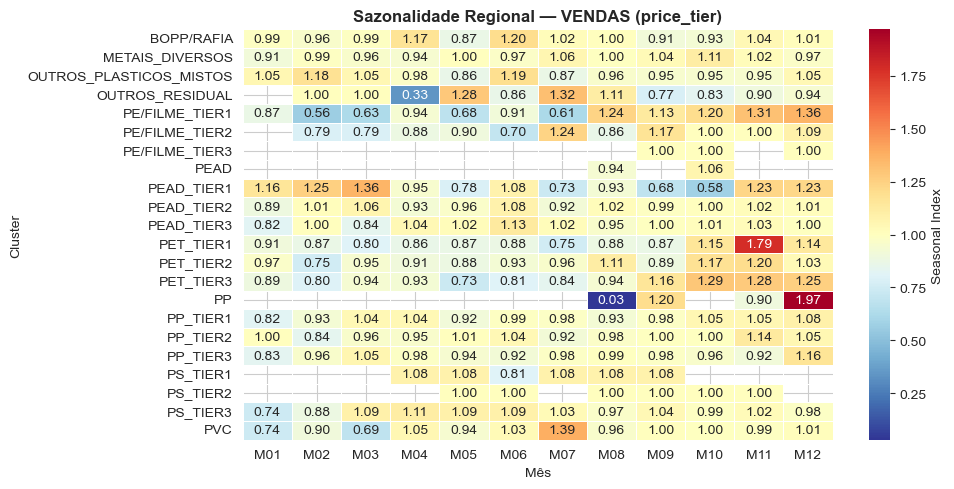

In [131]:
# === Fetch external macro data from BCB APIs ===
# %% PHASE 4: External Features + Cluster-Specific Features
import urllib.request
import json

# ---------------------------------------------------------------
# 1) USD/BRL — PTAX cotação de venda (média mensal)
# ---------------------------------------------------------------
ptax_url = (
    "https://olinda.bcb.gov.br/olinda/servico/PTAX/versao/v1/odata/"
    "CotacaoDolarPeriodo(dataInicial=@di,dataFinalCotacao=@df)"
    "?@di='01-01-2023'&@df='12-31-2025'"
    "&$select=cotacaoVenda,dataHoraCotacao&$format=json&$top=10000"
)

try:
    with urllib.request.urlopen(ptax_url, timeout=30) as resp:
        ptax_raw = json.loads(resp.read().decode("utf-8"))["value"]
    df_ptax = pd.DataFrame(ptax_raw)
    df_ptax["date"] = pd.to_datetime(df_ptax["dataHoraCotacao"])
    df_ptax["year"] = df_ptax["date"].dt.year
    df_ptax["month"] = df_ptax["date"].dt.month
    ptax_monthly = (
        df_ptax.groupby(["year", "month"])["cotacaoVenda"]
        .mean().reset_index()
        .rename(columns={"cotacaoVenda": "usd_brl_mean"})
    )
    ptax_monthly["usd_brl_mean"] = ptax_monthly["usd_brl_mean"].round(4)
    print(f"PTAX: {len(ptax_monthly)} meses carregados")
    display(ptax_monthly.tail())
except Exception as e:
    print(f"ERRO ao buscar PTAX: {e}")
    ptax_monthly = pd.DataFrame(columns=["year", "month", "usd_brl_mean"])

# ---------------------------------------------------------------
# 2) IPCA — variação mensal (série SGS 433)
# ---------------------------------------------------------------
ipca_url = (
    "https://api.bcb.gov.br/dados/serie/bcdata.sgs.433/dados"
    "?formato=json&dataInicial=01/01/2023&dataFinal=31/12/2025"
)

try:
    req = urllib.request.Request(ipca_url, headers={"Accept": "application/json"})
    with urllib.request.urlopen(req, timeout=30) as resp:
        ipca_raw = json.loads(resp.read().decode("utf-8"))
    df_ipca = pd.DataFrame(ipca_raw)
    df_ipca["data"] = pd.to_datetime(df_ipca["data"], format="%d/%m/%Y")
    df_ipca["year"] = df_ipca["data"].dt.year
    df_ipca["month"] = df_ipca["data"].dt.month
    df_ipca["ipca_monthly_pct"] = df_ipca["valor"].astype(float)
    df_ipca = df_ipca.sort_values("data")
    df_ipca["ipca_acc"] = (1 + df_ipca["ipca_monthly_pct"] / 100).cumprod() * 100
    ipca_monthly = df_ipca[["year", "month", "ipca_monthly_pct", "ipca_acc"]].copy()
    ipca_monthly["ipca_monthly_pct"] = ipca_monthly["ipca_monthly_pct"].round(4)
    ipca_monthly["ipca_acc"] = ipca_monthly["ipca_acc"].round(4)
    print(f"\nIPCA: {len(ipca_monthly)} meses carregados")
    display(ipca_monthly.tail())
except Exception as e:
    print(f"ERRO ao buscar IPCA: {e}")
    ipca_monthly = pd.DataFrame(columns=["year", "month", "ipca_monthly_pct", "ipca_acc"])

# ---------------------------------------------------------------
# 3) Merge macro features into monthly_feat
# ---------------------------------------------------------------
monthly_feat = monthly_feat.merge(ptax_monthly, on=["year", "month"], how="left")
monthly_feat = monthly_feat.merge(ipca_monthly, on=["year", "month"], how="left")

for col in ["usd_brl_mean", "ipca_monthly_pct", "ipca_acc"]:
    if col in monthly_feat.columns:
        monthly_feat[col] = monthly_feat[col].ffill().bfill()

print(f"\n--- Macro features merged into monthly_feat ---")
print(f"Shape: {monthly_feat.shape}")

# ---------------------------------------------------------------
# 4) Regional seasonality (uses best_cluster_col from optimizer)
# ---------------------------------------------------------------
train_mask = monthly_feat["year"].isin([2023, 2024])

group_state_mean = (
    monthly_feat[train_mask]
    .groupby([best_cluster_col, "emitterstateuf", "side"])["price_median"]
    .mean()
)
group_state_month_mean = (
    monthly_feat[train_mask]
    .groupby([best_cluster_col, "emitterstateuf", "side", "month"])["price_median"]
    .mean()
)
seasonal_index = (group_state_month_mean / group_state_mean).reset_index()
seasonal_index.columns = [best_cluster_col, "emitterstateuf", "side", "month", "seasonal_idx"]

monthly_feat = monthly_feat.merge(
    seasonal_index, on=[best_cluster_col, "emitterstateuf", "side", "month"], how="left"
)
monthly_feat["seasonal_idx"] = monthly_feat["seasonal_idx"].fillna(1.0)

print(f"\n--- Regional Seasonality Index (using {best_cluster_col}) ---")
print(f"Range: {monthly_feat['seasonal_idx'].min():.3f} – {monthly_feat['seasonal_idx'].max():.3f}")

# ---------------------------------------------------------------
# 5) Cluster heterogeneity features
# ---------------------------------------------------------------
heterogeneity = (
    df_price_clean.groupby([best_cluster_col, 'emitterstateuf'])
    .agg(
        n_products_in_cluster=('estoque_product', 'nunique'),
        price_spread_90_10=(price_col, lambda x: x.quantile(0.9) - x.quantile(0.1)),
    )
    .reset_index()
)

monthly_feat = monthly_feat.merge(
    heterogeneity,
    on=[best_cluster_col, 'emitterstateuf'],
    how='left'
)

# Herfindahl concentration index (product concentration within cluster)
prod_counts = (
    df_price_clean.groupby([best_cluster_col, 'emitterstateuf', 'year', 'month', 'estoque_product'])
    .size().reset_index(name='cnt')
)
totals = prod_counts.groupby([best_cluster_col, 'emitterstateuf', 'year', 'month'])['cnt'].transform('sum')
prod_counts['share'] = prod_counts['cnt'] / totals
concentration = (
    prod_counts.groupby([best_cluster_col, 'emitterstateuf', 'year', 'month'])
    .apply(lambda g: (g['share'] ** 2).sum(), include_groups=False)
    .reset_index(name='product_concentration')
)

monthly_feat = monthly_feat.merge(
    concentration,
    on=[best_cluster_col, 'emitterstateuf', 'year', 'month'],
    how='left'
)

# Fill NaN for new features
monthly_feat['product_concentration'] = monthly_feat['product_concentration'].fillna(1.0)
monthly_feat['n_products_in_cluster'] = monthly_feat['n_products_in_cluster'].fillna(1)
monthly_feat['price_spread_90_10'] = monthly_feat['price_spread_90_10'].fillna(0)

print(f"\n--- Cluster Heterogeneity Features (using {best_cluster_col}) ---")
print(f"n_products_in_cluster: mean={monthly_feat['n_products_in_cluster'].mean():.1f}")
print(f"price_spread_90_10:    mean={monthly_feat['price_spread_90_10'].mean():.2f} R$/kg")
print(f"product_concentration: mean={monthly_feat['product_concentration'].mean():.3f}")

# ---------------------------------------------------------------
# 6) Seasonality heatmap
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
sub = seasonal_index[seasonal_index["side"] == "VENDAS"]
pivot = sub.pivot_table(index=best_cluster_col, columns="month", values="seasonal_idx", aggfunc="mean")
pivot.columns = [f"M{int(m):02d}" for m in pivot.columns]
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlBu_r", center=1.0,
            ax=ax, linewidths=0.5, cbar_kws={"label": "Seasonal Index"})
ax.set_title(f"Sazonalidade Regional — VENDAS ({best_cluster_col})", fontweight="bold")
ax.set_ylabel("Cluster")
ax.set_xlabel("Mês")
plt.tight_layout()
plt.show()

## 5. Walk-Forward Cross-Validation (Expanding Window)

Validação temporal rigorosa: para cada mês de 2025, treina nos dados anteriores e prediz o mês seguinte.

- **Cluster key:** Selecionado pelo otimizador (Phase 3)
- **Target:** `price_fair` (robusto: mid-quartile ou mediana se houver divergência)
- **Features (14):** month_sin, month_cos, year, n_transactions, lag_3m, lag_6m, vol_lag_3m, usd_brl_mean, ipca_monthly_pct, ipca_acc, seasonal_idx, n_products_in_cluster, price_spread_90_10, product_concentration
- **Modelos:** LinearRegression, Ridge, RandomForest, XGBoost, LightGBM + baselines (Median, Lag3m)
- **Diagnóstico:** Rastreamento per-cluster de erros para identificar clusters problemáticos

In [133]:
# === Expanding Window Time Series Cross-Validation ===
# %% PHASE 5: Enhanced Walk-Forward CV with Cluster Optimization

# Dynamic feature set based on clusterization
FEATURES = [
    "month_sin", "month_cos", "year", "n_transactions",
    "lag_3m", "lag_6m", "vol_lag_3m",
    "usd_brl_mean", "ipca_monthly_pct", "ipca_acc", "seasonal_idx",
    # Heterogeneity features
    "n_products_in_cluster", "price_spread_90_10", "product_concentration",
]

# Remove features that don't exist or are entirely NaN
FEATURES = [f for f in FEATURES if f in monthly_feat.columns and monthly_feat[f].notna().any()]

# Use robust consensus target
TARGET = "price_fair"
# Fallback if price_fair not available
if TARGET not in monthly_feat.columns:
    TARGET = "price_median"

group_key = best_cluster_col  # From optimizer

# Fill remaining NaN in features with column median (handles partial NaN from API failures)
for f in FEATURES:
    if monthly_feat[f].isna().any():
        monthly_feat[f] = monthly_feat[f].fillna(monthly_feat[f].median())

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Target: {TARGET}")
print(f"Group key: {group_key}\n")

# Model specs
model_specs = [
    ("LinearRegression", LinearRegression()),
    ("Ridge", Ridge(alpha=1.0)),
    ("RandomForest", RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)),
]
if HAS_XGB:
    model_specs.append(("XGBoost", XGBRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbosity=0)))
if HAS_LGBM:
    model_specs.append(("LightGBM", LGBMRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, verbose=-1)))

# Evaluation utility
def evaluate_predictions(y_true, y_pred, label):
    mask = ~(y_true.isna() | y_pred.isna())
    y_t, y_p = y_true[mask], y_pred[mask]
    if len(y_t) == 0:
        return {"model": label, "n": 0, "MAE": np.nan, "RMSE": np.nan, "R2": np.nan, "MAPE_%": np.nan}
    mae = mean_absolute_error(y_t, y_p)
    rmse = np.sqrt(mean_squared_error(y_t, y_p))
    r2 = r2_score(y_t, y_p)
    mape = (np.abs((y_t - y_p) / y_t.clip(lower=0.01)) * 100).median()
    return {"model": label, "n": len(y_t), "MAE": round(mae, 4),
            "RMSE": round(rmse, 4), "R2": round(r2, 4), "MAPE_%": round(mape, 1)}

# --- Discover 2025 months ---
months_2025 = sorted(monthly_feat[monthly_feat["year"] == 2025]["date"].unique())
print(f"Meses de teste (2025): {len(months_2025)}")
for m in months_2025:
    print(f"  {pd.Timestamp(m).strftime('%Y-%m')}")

# --- Walk-forward loop ---
cv_fold_predictions = []
cv_monthly_scores = []
trained_models = {}
per_cluster_errors = []  # Track per-cluster performance

for fold_idx, target_date in enumerate(months_2025):
    target_month = pd.Timestamp(target_date)
    month_label = target_month.strftime("%Y-%m")

    train_fold = monthly_feat[monthly_feat["date"] < target_month].copy()
    test_fold = monthly_feat[monthly_feat["date"] == target_month].copy()

    if len(test_fold) == 0:
        continue

    print(f"\n{'='*55}")
    print(f"  Fold {fold_idx+1}: Train → antes de {month_label} ({len(train_fold)} rows)")
    print(f"         Test  → {month_label} ({len(test_fold)} rows)")
    print(f"{'='*55}")

    side = "VENDAS"
    tr = train_fold[train_fold["side"] == side]
    te = test_fold[test_fold["side"] == side].copy()

    if len(tr) < 10 or len(te) == 0:
        if len(te) > 0:
            print(f"  {side}: treino insuficiente ({len(tr)} rows) — pulando")
        continue

    X_tr = tr[FEATURES].values
    y_tr = tr[TARGET].values
    X_te = te[FEATURES].values
    y_te = te[TARGET].values

    # --- Baseline 1: Median per (cluster, state) from train ---
    medians = tr.groupby([group_key, "emitterstateuf"])[TARGET].median().to_dict()
    te["pred_Median"] = te.apply(
        lambda r: medians.get((r[group_key], r["emitterstateuf"]), np.nan), axis=1
    )
    # --- Baseline 2: Lag3m ---
    te["pred_Lag3m"] = te["lag_3m"]

    for bname in ["Median", "Lag3m"]:
        res = evaluate_predictions(
            pd.Series(y_te, index=te.index),
            te[f"pred_{bname}"],
            f"{bname} ({side})"
        )
        res["month"] = month_label
        res["side"] = side
        cv_monthly_scores.append(res)

    # --- ML Models ---
    for name, model_template in model_specs:
        model = clone(model_template)
        model.fit(X_tr, y_tr)
        y_pred = np.clip(model.predict(X_te), 0, None)
        te[f"pred_{name}"] = y_pred

        res = evaluate_predictions(
            pd.Series(y_te, index=te.index),
            pd.Series(y_pred, index=te.index),
            f"{name} ({side})"
        )
        res["month"] = month_label
        res["side"] = side
        cv_monthly_scores.append(res)

        trained_models[(side, name)] = model
        print(f"  {side} | {name}: MAE={res['MAE']:.4f}")

    # Track per-cluster errors for diagnostics
    for cluster_id in te[group_key].unique():
        cluster_te = te[te[group_key] == cluster_id]
        cluster_y = cluster_te[TARGET].values
        for mname in ["Lag3m", "RandomForest"]:
            pcol = f"pred_{mname}"
            if pcol in cluster_te.columns:
                cluster_pred = cluster_te[pcol].values
                valid = ~(np.isnan(cluster_y) | np.isnan(cluster_pred))
                if valid.sum() > 0:
                    per_cluster_errors.append({
                        'cluster': cluster_id,
                        'state': cluster_te['emitterstateuf'].iloc[0],
                        'month': month_label,
                        'model': mname,
                        'mae': np.abs(cluster_y[valid] - cluster_pred[valid]).mean(),
                        'n_train': len(tr[tr[group_key] == cluster_id]),
                        'actual_price': cluster_y[valid].mean(),
                    })

    cv_fold_predictions.append(te)

# --- Assemble full test set with predictions ---
test = pd.concat(cv_fold_predictions, ignore_index=True)
df_cv_scores = pd.DataFrame(cv_monthly_scores)

print(f"\n\nTotal de previsões acumuladas: {len(test)} rows")
print(f"Folds executados: {len(months_2025)}")

# --- Per-cluster performance summary ---
if per_cluster_errors:
    cluster_perf = pd.DataFrame(per_cluster_errors)
    poor_clusters = (
        cluster_perf.groupby(['cluster', 'state', 'model'])
        .agg(mae=('mae', 'mean'), n_train=('n_train', 'first'), actual_price=('actual_price', 'mean'))
        .reset_index()
        .sort_values('mae', ascending=False)
    )
    print(f"\nTop 10 worst performing cluster-state pairs (Lag3m):")
    display(poor_clusters[poor_clusters['model'] == 'Lag3m'].head(10))

Features (11): ['month_sin', 'month_cos', 'year', 'n_transactions', 'lag_3m', 'lag_6m', 'vol_lag_3m', 'seasonal_idx', 'n_products_in_cluster', 'price_spread_90_10', 'product_concentration']
Target: price_fair
Group key: price_tier

Meses de teste (2025): 12
  2025-01
  2025-02
  2025-03
  2025-04
  2025-05
  2025-06
  2025-07
  2025-08
  2025-09
  2025-10
  2025-11
  2025-12

  Fold 1: Train → antes de 2025-01 (1751 rows)
         Test  → 2025-01 (94 rows)
  VENDAS | LinearRegression: MAE=0.7048
  VENDAS | Ridge: MAE=0.7041
  VENDAS | RandomForest: MAE=0.6513
  VENDAS | XGBoost: MAE=0.7489
  VENDAS | LightGBM: MAE=0.7179

  Fold 2: Train → antes de 2025-02 (1845 rows)
         Test  → 2025-02 (100 rows)
  VENDAS | LinearRegression: MAE=0.5838
  VENDAS | Ridge: MAE=0.5832
  VENDAS | RandomForest: MAE=0.4840


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  VENDAS | XGBoost: MAE=0.4642
  VENDAS | LightGBM: MAE=0.5314

  Fold 3: Train → antes de 2025-03 (1945 rows)
         Test  → 2025-03 (94 rows)
  VENDAS | LinearRegression: MAE=0.5110
  VENDAS | Ridge: MAE=0.5104
  VENDAS | RandomForest: MAE=0.4209


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  VENDAS | XGBoost: MAE=0.3924
  VENDAS | LightGBM: MAE=0.4632

  Fold 4: Train → antes de 2025-04 (2039 rows)
         Test  → 2025-04 (109 rows)
  VENDAS | LinearRegression: MAE=0.4491
  VENDAS | Ridge: MAE=0.4486
  VENDAS | RandomForest: MAE=0.4051


...

  VENDAS | RandomForest: MAE=0.3378
  VENDAS | XGBoost: MAE=0.3411
  VENDAS | LightGBM: MAE=0.3414

  Fold 12: Train → antes de 2025-12 (2904 rows)
         Test  → 2025-12 (107 rows)
  VENDAS | LinearRegression: MAE=0.5089
  VENDAS | Ridge: MAE=0.5087


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  VENDAS | RandomForest: MAE=0.4460
  VENDAS | XGBoost: MAE=0.4541
  VENDAS | LightGBM: MAE=0.4156


Total de previsões acumuladas: 1260 rows
Folds executados: 12

Top 10 worst performing cluster-state pairs (Lag3m):


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,cluster,state,model,mae,n_train,actual_price
10,METAIS_DIVERSOS,ES,Lag3m,1.426078,119,9.690835
68,PET,RS,Lag3m,1.212682,0,1.662682
50,PEAD_TIER1,CE,Lag3m,1.031667,50,0.535000
8,METAIS_DIVERSOS,DF,Lag3m,0.967905,196,9.317187
90,PET_TIER3,ES,Lag3m,0.799475,151,4.113494
96,PP,RS,Lag3m,0.790000,5,1.450000
84,PET_TIER2,ES,Lag3m,0.780357,158,3.291071
88,PET_TIER3,BA,Lag3m,0.763851,219,3.798488
22,OUTROS_RESIDUAL,GO,Lag3m,0.725000,51,1.225000
18,OUTROS_RESIDUAL,BA,Lag3m,0.700000,47,1.366667


## 6. Resultados da Validação Cruzada

Métricas **por mês** e resumo **global** (média das métricas mensais) para cada modelo — apenas VENDAS.


  VENDAS — Métricas por mês


model,Lag3m (VENDAS),LightGBM (VENDAS),LinearRegression (VENDAS),Median (VENDAS),RandomForest (VENDAS),Ridge (VENDAS),XGBoost (VENDAS)
month,,,,,,,
2025-01,0.6030,0.7179,0.7048,0.6707,0.6513,0.7041,0.7489
2025-02,0.4659,0.5314,0.5838,0.7067,0.4840,0.5832,0.4642
2025-03,0.3842,0.4632,0.5110,0.7173,0.4209,0.5104,0.3924
2025-04,0.3457,0.4033,0.4491,0.6387,0.4051,0.4486,0.4203
2025-05,0.6560,0.6113,0.7172,0.5868,0.6027,0.7167,0.6013
2025-06,0.4814,0.4466,0.5844,0.5529,0.4553,0.5836,0.3923
2025-07,0.2740,0.3533,0.4569,0.5464,0.3562,0.4565,0.3492
2025-08,0.2692,0.3072,0.3541,0.4901,0.3076,0.3538,0.3396
2025-09,0.2985,0.3415,0.3531,0.5151,0.3268,0.3528,0.3135


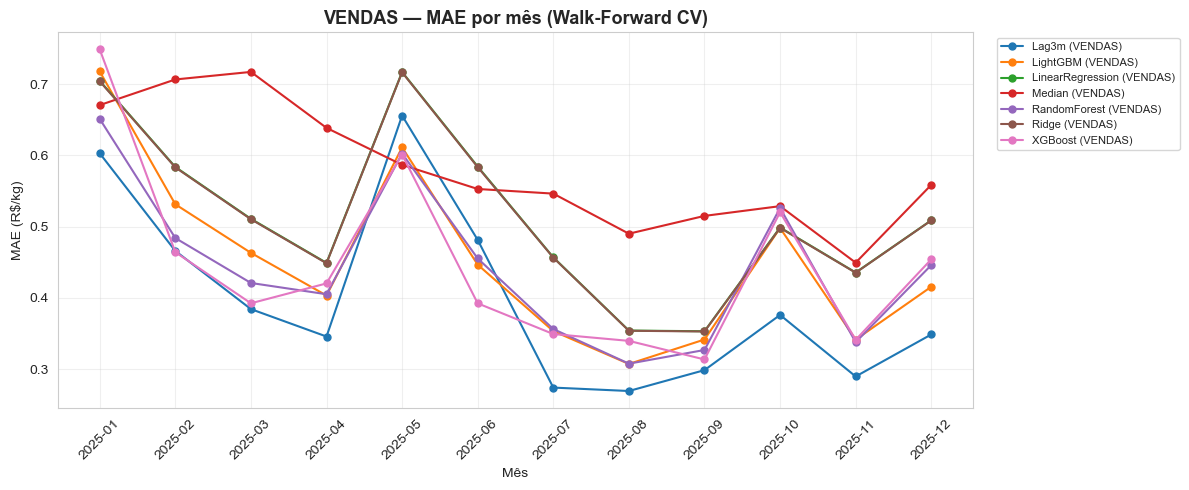


  RESUMO GLOBAL — Média das métricas sobre todos os folds


,model,side,n_folds,n_total,MAE_mean,MAE_std,RMSE_mean,R2_mean,MAPE_%_mean
0,Lag3m (VENDAS),VENDAS,12,1260,0.3993,0.1278,0.8300,0.8638,9.7
4,RandomForest (VENDAS),VENDAS,12,1260,0.4433,0.1087,0.8037,0.8761,13.4
6,XGBoost (VENDAS),VENDAS,12,1260,0.4448,0.1270,0.8077,0.8733,13.7
1,LightGBM (VENDAS),VENDAS,12,1260,0.4526,0.1219,0.8072,0.8764,14.0
5,Ridge (VENDAS),VENDAS,12,1260,0.5127,0.1178,0.8616,0.8624,19.0
2,LinearRegression (VENDAS),VENDAS,12,1260,0.5131,0.1179,0.8620,0.8623,19.0
3,Median (VENDAS),VENDAS,12,1232,0.5801,0.0858,1.0206,0.8248,18.6



Melhor modelo VENDAS: Lag3m (VENDAS) — MAE médio = 0.3993 ± 0.1278


In [134]:
# === CV Results: per-month and global summary ===

side = "VENDAS"
side_scores = df_cv_scores[df_cv_scores["side"] == side].copy()
if not side_scores.empty:
    print(f"\n{'='*65}")
    print(f"  {side} — Métricas por mês")
    print(f"{'='*65}")

    # Pivot: rows = months, columns = models, values = MAE
    pivot_mae = side_scores.pivot(index="month", columns="model", values="MAE")
    pivot_mae = pivot_mae[[c for c in sorted(pivot_mae.columns)]]
    display(pivot_mae.round(4))

    # --- Line chart: MAE per month per model ---
    fig, ax = plt.subplots(figsize=(12, 5))
    for col in pivot_mae.columns:
        ax.plot(pivot_mae.index, pivot_mae[col], "o-", label=col, linewidth=1.5, markersize=5)
    ax.set_title(f"{side} — MAE por mês (Walk-Forward CV)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Mês")
    ax.set_ylabel("MAE (R$/kg)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# === Global summary: average metrics across all folds ===
print(f"\n{'='*65}")
print(f"  RESUMO GLOBAL — Média das métricas sobre todos os folds")
print(f"{'='*65}")

all_results = []
for (model_name, side_name), grp in df_cv_scores.groupby(["model", "side"]):
    all_results.append({
        "model": model_name,
        "side": side_name,
        "n_folds": len(grp),
        "n_total": grp["n"].sum(),
        "MAE_mean": round(grp["MAE"].mean(), 4),
        "MAE_std": round(grp["MAE"].std(), 4),
        "RMSE_mean": round(grp["RMSE"].mean(), 4),
        "R2_mean": round(grp["R2"].mean(), 4),
        "MAPE_%_mean": round(grp["MAPE_%"].mean(), 1),
    })

df_all_results = pd.DataFrame(all_results).sort_values(["side", "MAE_mean"])
display(df_all_results)

# Best model
best_models = {}
side_df = df_all_results[df_all_results["side"] == "VENDAS"]
if not side_df.empty:
    best_row = side_df.iloc[0]  # already sorted by MAE_mean
    best_models["VENDAS"] = best_row["model"]
    print(f"\nMelhor modelo VENDAS: {best_row['model']} — MAE médio = {best_row['MAE_mean']:.4f} ± {best_row['MAE_std']:.4f}")

## 6b. Acurácia por Estado e Estado × Material

Quebrando a avaliação do melhor modelo por **estado** e por **estado × grupo de material** para entender onde os modelos performam melhor e onde há mais erro.


  VENDAS — MAE por Estado (best model: Lag3m)


,state,n_obs,MAE_Lag3m,MAE_Median,MAE_LinearRegression,MAE_Ridge,MAE_RandomForest,MAE_XGBoost,MAE_LightGBM
0,AL,4,0.0000,0.0000,0.1840,0.1833,0.0143,0.0588,0.0430
1,AM,7,0.0411,0.0275,0.1495,0.1493,0.0818,0.0837,0.0963
10,MT,1,0.0600,0.0600,0.2824,0.2819,0.0916,0.0611,0.0536
14,PI,2,0.0700,0.0700,0.3204,0.3199,0.1149,0.1240,0.1348
7,MA,50,0.1117,0.1929,0.2387,0.2382,0.1428,0.1485,0.1520
15,PR,152,0.2476,0.5167,0.3139,0.3136,0.2656,0.3026,0.2821
18,RS,169,0.2544,0.4165,0.3351,0.3347,0.2961,0.2880,0.2790
8,MG,137,0.2577,0.3437,0.3681,0.3677,0.3224,0.3212,0.3402
13,PE,17,0.2724,0.7296,1.0559,1.0552,0.4176,0.3934,0.4402
4,DF,48,0.3472,0.4503,0.4514,0.4509,0.4265,0.4526,0.4022


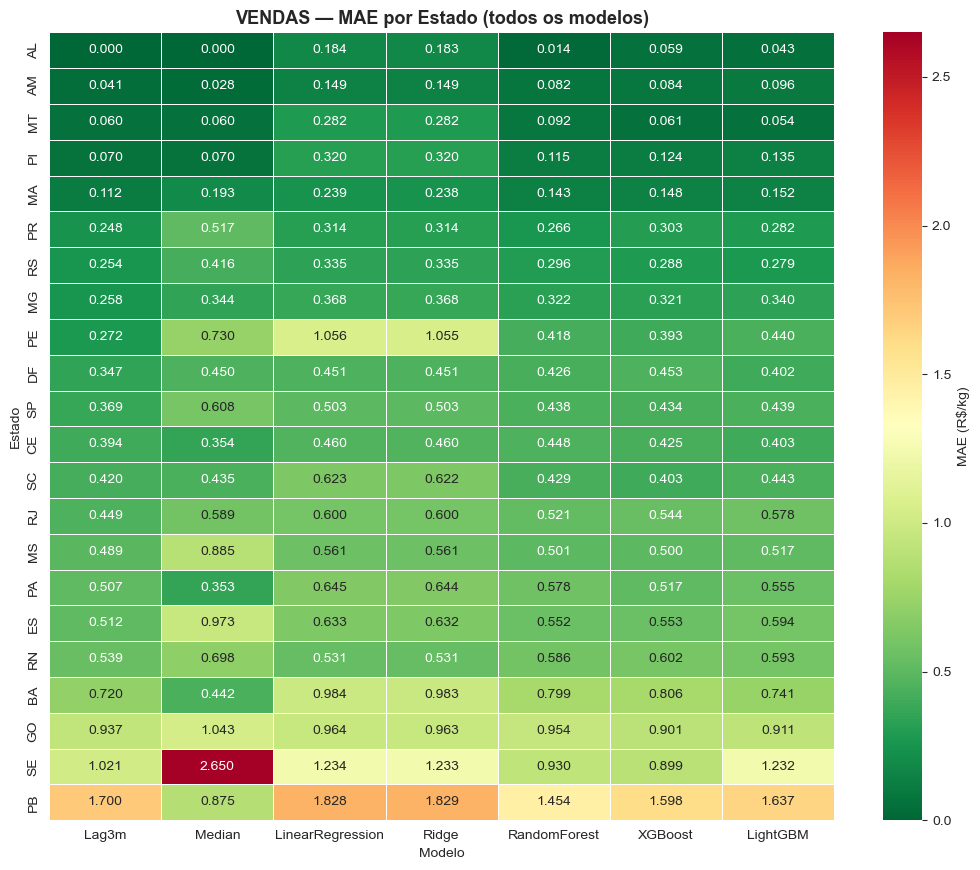


  VENDAS — MAE por Estado × price_tier (best model: Lag3m)


,state,price_tier,n_obs,MAE_Lag3m,MAE_Median
0,AL,OUTROS_PLASTICOS_MISTOS,4,0.0000,0.0000
167,SP,PS_TIER1,2,0.0000,0.0000
156,SP,OUTROS_RESIDUAL,1,0.0000,0.0000
145,SC,BOPP/RAFIA,8,0.0000,0.0094
123,RN,PP_TIER1,2,0.0000,0.0000
...,...,...,...,...,...
75,MS,OUTROS_RESIDUAL,1,2.7000,NaN
147,SC,PEAD_TIER2,2,2.8000,2.8000
18,DF,METAIS_DIVERSOS,1,3.4057,5.0000
7,BA,PET_TIER3,3,3.6667,0.7417


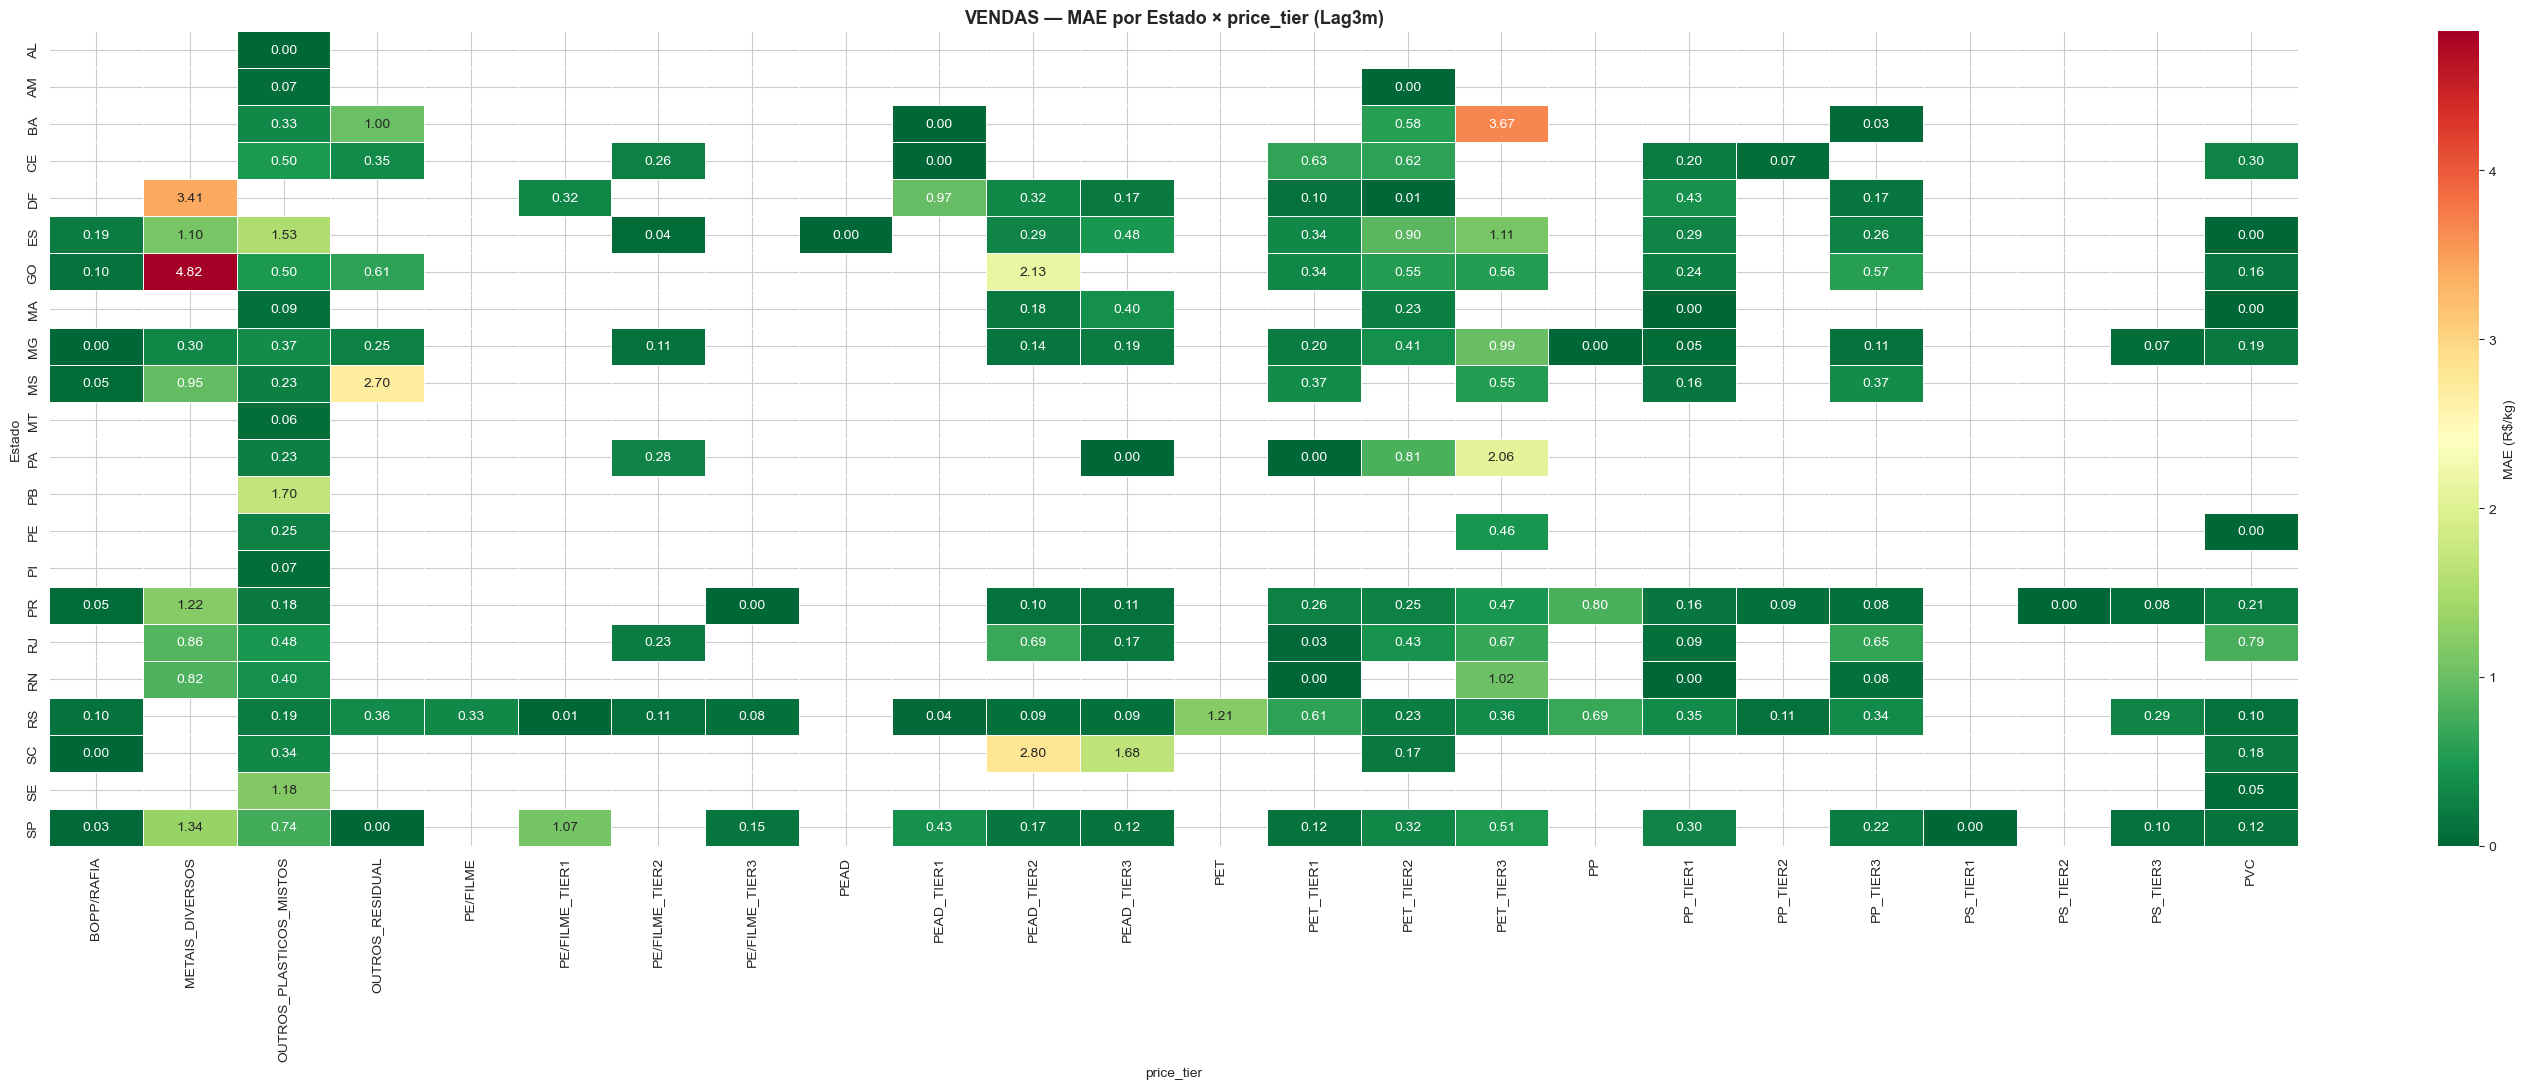


  Top 10 pares com MENOR MAE (Lag3m):


,state,price_tier,n_obs,MAE_Lag3m
0,AL,OUTROS_PLASTICOS_MISTOS,4,0.0
167,SP,PS_TIER1,2,0.0
156,SP,OUTROS_RESIDUAL,1,0.0
145,SC,BOPP/RAFIA,8,0.0
123,RN,PP_TIER1,2,0.0
121,RN,PET_TIER1,1,0.0
105,PR,PS_TIER2,1,0.0
95,PR,PE/FILME_TIER3,9,0.0
90,PE,PVC,6,0.0
83,PA,PEAD_TIER3,3,0.0



  Top 10 pares com MAIOR MAE (Lag3m):


,state,price_tier,n_obs,MAE_Lag3m
29,ES,OUTROS_PLASTICOS_MISTOS,3,1.5333
148,SC,PEAD_TIER3,2,1.6750
87,PB,OUTROS_PLASTICOS_MISTOS,4,1.7000
86,PA,PET_TIER3,2,2.0600
44,GO,PEAD_TIER2,1,2.1300
75,MS,OUTROS_RESIDUAL,1,2.7000
147,SC,PEAD_TIER2,2,2.8000
18,DF,METAIS_DIVERSOS,1,3.4057
7,BA,PET_TIER3,3,3.6667
41,GO,METAIS_DIVERSOS,8,4.8231


In [135]:
# === Accuracy breakdown by State and State × Cluster ===

pred_cols = [c for c in test.columns if c.startswith("pred_")]
model_names_eval = [c.replace("pred_", "") for c in pred_cols]

side = "VENDAS"
te = test[test["side"] == side].copy()

best_model_name = best_models.get(side)
if best_model_name is not None:
    best_short = best_model_name.replace(f" ({side})", "")
    best_pred_col = f"pred_{best_short}"

    if best_pred_col in te.columns:
        compare_models = [best_short] + [m for m in model_names_eval if m != best_short]

        # ---------------------------------------------------------------
        # 1) MAE by STATE
        # ---------------------------------------------------------------
        print(f"\n{'='*65}")
        print(f"  {side} — MAE por Estado (best model: {best_short})")
        print(f"{'='*65}")

        state_metrics = []
        for state, grp_df in te.groupby("emitterstateuf"):
            row = {"state": state, "n_obs": len(grp_df)}
            for mname in compare_models:
                col = f"pred_{mname}"
                if col in grp_df.columns:
                    valid = grp_df.dropna(subset=[col])
                    if len(valid) > 0:
                        row[f"MAE_{mname}"] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                    else:
                        row[f"MAE_{mname}"] = np.nan
            state_metrics.append(row)

        df_state = pd.DataFrame(state_metrics).sort_values(f"MAE_{best_short}")
        display(df_state)

        # --- Heatmap: MAE by state for top models ---
        mae_cols = [c for c in df_state.columns if c.startswith("MAE_")]
        if len(mae_cols) > 0 and len(df_state) >= 3:
            fig, ax = plt.subplots(figsize=(max(8, len(mae_cols) * 1.5), max(5, len(df_state) * 0.4)))
            hm_data = df_state.set_index("state")[mae_cols].rename(columns=lambda c: c.replace("MAE_", ""))
            sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=ax,
                        linewidths=0.5, cbar_kws={"label": "MAE (R$/kg)"})
            ax.set_title(f"{side} — MAE por Estado (todos os modelos)", fontsize=13, fontweight="bold")
            ax.set_ylabel("Estado")
            ax.set_xlabel("Modelo")
            plt.tight_layout()
            plt.show()

        # ---------------------------------------------------------------
        # 2) MAE by STATE × CLUSTER (uses best_cluster_col dynamically)
        # ---------------------------------------------------------------
        print(f"\n{'='*65}")
        print(f"  {side} — MAE por Estado × {group_key} (best model: {best_short})")
        print(f"{'='*65}")

        pair_metrics = []
        for (state, grp_name), grp_df in te.groupby(["emitterstateuf", group_key]):
            row = {"state": state, group_key: grp_name, "n_obs": len(grp_df)}
            for mname in [best_short, "Lag3m", "Median"]:
                col = f"pred_{mname}"
                if col in grp_df.columns:
                    valid = grp_df.dropna(subset=[col])
                    if len(valid) > 0:
                        row[f"MAE_{mname}"] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                    else:
                        row[f"MAE_{mname}"] = np.nan
            pair_metrics.append(row)

        df_pairs = pd.DataFrame(pair_metrics).sort_values(f"MAE_{best_short}")
        display(df_pairs)

        # --- Heatmap: MAE by state × cluster for best model ---
        cluster_vals = sorted(te[group_key].unique())
        pivot_pairs = df_pairs.pivot(index="state", columns=group_key, values=f"MAE_{best_short}")
        pivot_pairs = pivot_pairs[[g for g in cluster_vals if g in pivot_pairs.columns]]
        if not pivot_pairs.empty:
            fig, ax = plt.subplots(figsize=(max(12, len(cluster_vals) * 1.2), max(4, len(pivot_pairs) * 0.5)))
            sns.heatmap(pivot_pairs, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax,
                        linewidths=0.5, cbar_kws={"label": "MAE (R$/kg)"})
            ax.set_title(f"{side} — MAE por Estado × {group_key} ({best_short})",
                         fontsize=13, fontweight="bold")
            ax.set_ylabel("Estado")
            ax.set_xlabel(group_key)
            plt.tight_layout()
            plt.show()

        # --- Top 10 best and worst pairs ---
        valid_pairs = df_pairs.dropna(subset=[f"MAE_{best_short}"])
        if len(valid_pairs) >= 5:
            print(f"\n  Top 10 pares com MENOR MAE ({best_short}):")
            display(valid_pairs.head(10)[["state", group_key, "n_obs", f"MAE_{best_short}"]])
            print(f"\n  Top 10 pares com MAIOR MAE ({best_short}):")
            display(valid_pairs.tail(10)[["state", group_key, "n_obs", f"MAE_{best_short}"]])

## 6c. Acurácia por Tier de Qualidade dos Dados

Cruzando a avaliação do walk-forward CV com os **tiers de qualidade** definidos na análise de cobertura (A/B/C/D) para isolar se o erro de previsão está associado à quantidade/cobertura dos dados históricos.

Distribuição dos tiers no test set:


quality
A (excellent)       577
B (good)            382
C (fair)            236
D (insufficient)     65
Name: count, dtype: int64


  VENDAS — MAE por Tier de Qualidade dos Dados


,quality_tier,n_obs,MAE_Median,MAE_Lag3m,MAE_LinearRegression,MAE_Ridge,MAE_RandomForest,MAE_XGBoost,MAE_LightGBM
0,A (excellent),577,0.6956,0.3817,0.5273,0.5268,0.4572,0.4720,0.4831
1,B (good),382,0.5731,0.4694,0.5749,0.5744,0.4790,0.4579,0.4721
2,C (fair),236,0.3153,0.2892,0.3690,0.3687,0.3366,0.3361,0.3253
3,D (insufficient),65,0.3734,0.4410,0.4462,0.4462,0.4353,0.4439,0.4359


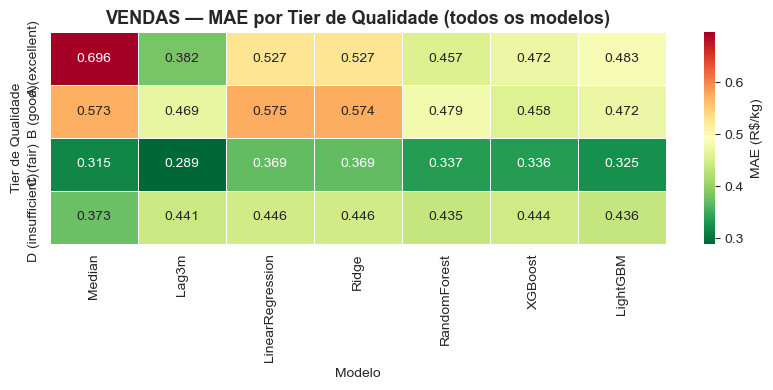

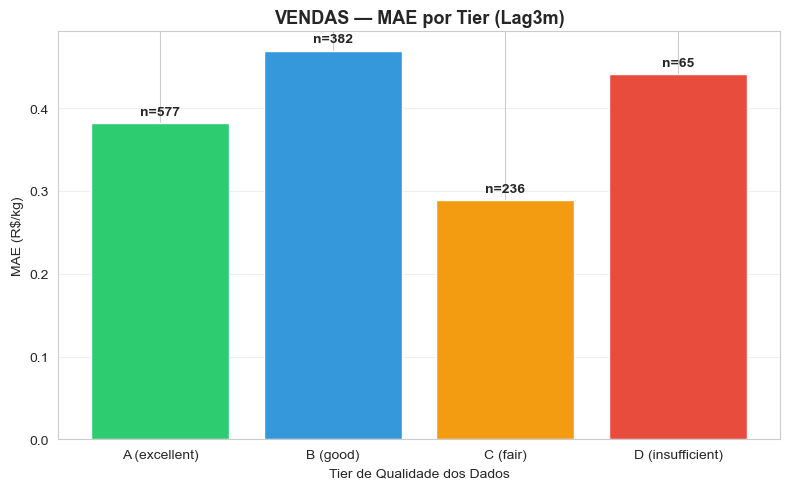

In [136]:
# === Accuracy breakdown by Data Quality Tier ===

# Rebuild coverage using best_cluster_col
coverage_opt = (
    df_price_clean.groupby([group_key, "emitterstateuf"])
    .agg(
        n_rows=(price_col, "count"),
        n_months=("year_month", "nunique"),
    ).reset_index()
)
coverage_opt["quality"] = coverage_opt.apply(quality_tier, axis=1)

# Merge quality tier labels into test predictions
test_qt = test.merge(
    coverage_opt[[group_key, "emitterstateuf", "quality"]],
    on=[group_key, "emitterstateuf"],
    how="left",
)
test_qt["quality"] = test_qt["quality"].fillna("D (insufficient)")

print(f"Distribuição dos tiers no test set:")
display(test_qt["quality"].value_counts().sort_index())

pred_cols = [c for c in test_qt.columns if c.startswith("pred_")]
model_names_qt = [c.replace("pred_", "") for c in pred_cols]

side = "VENDAS"
te = test_qt[test_qt["side"] == side].copy()
if len(te) > 0:
    print(f"\n{'='*65}")
    print(f"  {side} — MAE por Tier de Qualidade dos Dados")
    print(f"{'='*65}")

    tier_metrics = []
    for tier, grp_df in te.groupby("quality"):
        row = {"quality_tier": tier, "n_obs": len(grp_df)}
        for mname in model_names_qt:
            col = f"pred_{mname}"
            if col in grp_df.columns:
                valid = grp_df.dropna(subset=[col])
                if len(valid) > 0:
                    row[f"MAE_{mname}"] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                else:
                    row[f"MAE_{mname}"] = np.nan
        tier_metrics.append(row)

    df_tier = pd.DataFrame(tier_metrics).sort_values("quality_tier")
    display(df_tier)

    # --- Heatmap: MAE by tier for all models ---
    mae_cols_t = [c for c in df_tier.columns if c.startswith("MAE_")]
    if len(mae_cols_t) > 0 and len(df_tier) >= 2:
        fig, ax = plt.subplots(figsize=(max(8, len(mae_cols_t) * 1.2), 4))
        hm_data = df_tier.set_index("quality_tier")[mae_cols_t].rename(columns=lambda c: c.replace("MAE_", ""))
        sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=ax,
                    linewidths=0.5, cbar_kws={"label": "MAE (R$/kg)"})
        ax.set_title(f"{side} — MAE por Tier de Qualidade (todos os modelos)", fontsize=13, fontweight="bold")
        ax.set_ylabel("Tier de Qualidade")
        ax.set_xlabel("Modelo")
        plt.tight_layout()
        plt.show()

    # --- Bar chart: MAE comparison across tiers for best model ---
    best_model_name = best_models.get(side)
    if best_model_name:
        best_short = best_model_name.replace(f" ({side})", "")
        best_col = f"MAE_{best_short}"
        if best_col in df_tier.columns:
            fig, ax = plt.subplots(figsize=(8, 5))
            colors = {"A (excellent)": "#2ecc71", "B (good)": "#3498db",
                      "C (fair)": "#f39c12", "D (insufficient)": "#e74c3c"}
            bars = df_tier.dropna(subset=[best_col])
            bar_colors = [colors.get(t, "gray") for t in bars["quality_tier"]]
            ax.bar(bars["quality_tier"], bars[best_col], color=bar_colors, edgecolor="white")
            for i, (tier, val, n) in enumerate(zip(bars["quality_tier"], bars[best_col], bars["n_obs"])):
                ax.text(i, val + 0.01, f"n={n}", ha="center", fontsize=10, fontweight="bold")
            ax.set_title(f"{side} — MAE por Tier ({best_short})", fontsize=13, fontweight="bold")
            ax.set_ylabel("MAE (R$/kg)")
            ax.set_xlabel("Tier de Qualidade dos Dados")
            ax.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()

## 7. Feature Importance

Importância das features nos modelos tree-based (Random Forest, XGBoost, LightGBM).

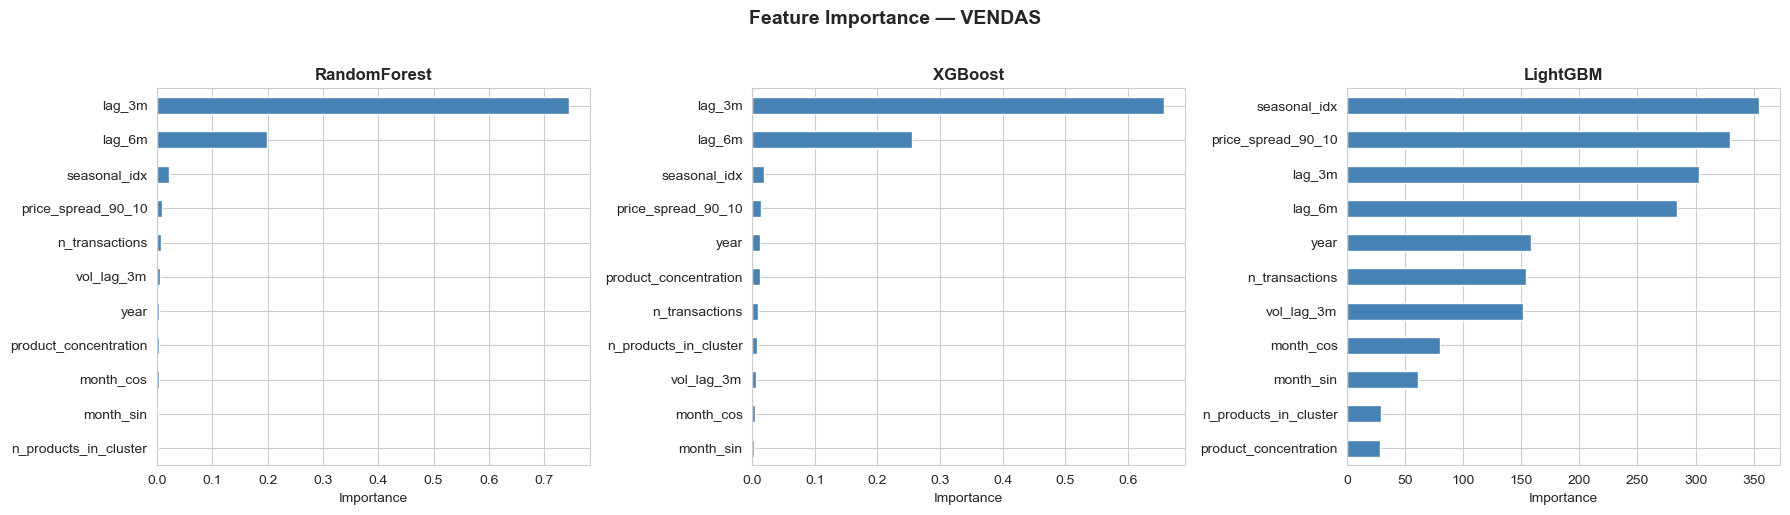

In [137]:
# === Feature importance from tree-based models ===

tree_models = [n for n in ["RandomForest", "XGBoost", "LightGBM"]
               if ("VENDAS", n) in trained_models]

if tree_models:
    fig, axes = plt.subplots(1, len(tree_models), figsize=(6 * len(tree_models), 5))
    if len(tree_models) == 1:
        axes = [axes]

    for ax, mname in zip(axes, tree_models):
        imp = trained_models[("VENDAS", mname)].feature_importances_
        feat_imp = pd.Series(imp, index=FEATURES).sort_values(ascending=True)
        feat_imp.plot(kind="barh", ax=ax, color="steelblue")
        ax.set_title(f"{mname}", fontweight="bold")
        ax.set_xlabel("Importance")

    plt.suptitle("Feature Importance — VENDAS",
                 fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("No tree-based models were trained.")

## 7b. Diagnóstico de Heterogeneidade vs Performance

Análise de como a heterogeneidade intra-cluster (spread de preço, número de produtos) afeta a qualidade das previsões. Clusters com alta dispersão e muitos produtos tendem a ter MAE mais alto.

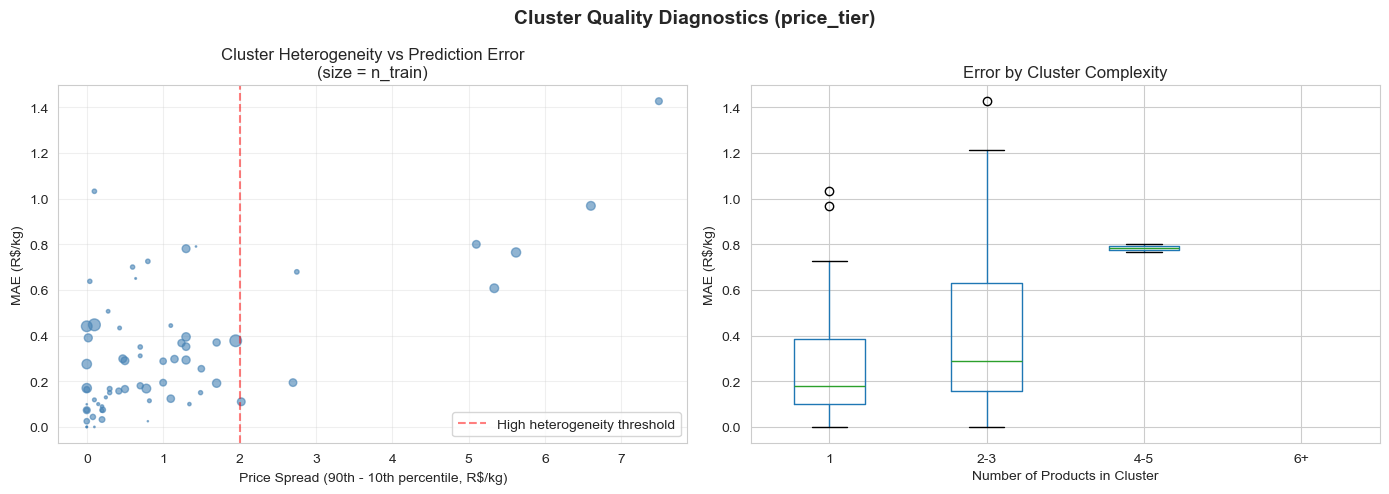


Clusters needing further splitting (7):


,cluster,state,mae,price_spread_90_10,n_products_in_cluster
0,METAIS_DIVERSOS,ES,1.426078,7.490000,2
1,PET,RS,1.212682,3.050000,2
3,METAIS_DIVERSOS,DF,0.967905,6.599595,1
4,PET_TIER3,ES,0.799475,5.100000,4
7,PET_TIER3,BA,0.763851,5.620000,4
10,PEAD_TIER1,DF,0.678889,2.750000,1
13,PET_TIER2,MG,0.607143,5.335000,3


In [138]:
# %% PHASE 6: Heterogeneity vs Performance Analysis

if per_cluster_errors:
    cluster_perf = pd.DataFrame(per_cluster_errors)

    # Aggregate: mean MAE per cluster-state across all folds
    poor_clusters = (
        cluster_perf[cluster_perf['model'] == 'Lag3m']
        .groupby(['cluster', 'state'])
        .agg(mae=('mae', 'mean'), n_train=('n_train', 'first'), actual_price=('actual_price', 'mean'))
        .reset_index()
        .sort_values('mae', ascending=False)
    )

    # Merge performance with heterogeneity metrics
    diagnostic = poor_clusters.merge(
        heterogeneity,
        left_on=['cluster', 'state'],
        right_on=[best_cluster_col, 'emitterstateuf'],
        how='left'
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Scatter: Heterogeneity vs MAE
    valid_diag = diagnostic.dropna(subset=['price_spread_90_10', 'mae'])
    if len(valid_diag) > 0:
        axes[0].scatter(valid_diag['price_spread_90_10'], valid_diag['mae'],
                       s=valid_diag['n_train'].clip(upper=500) / 5, alpha=0.6, c='steelblue')
        axes[0].set_xlabel("Price Spread (90th - 10th percentile, R$/kg)")
        axes[0].set_ylabel("MAE (R$/kg)")
        axes[0].set_title("Cluster Heterogeneity vs Prediction Error\n(size = n_train)")
        axes[0].axvline(2.0, color='red', linestyle='--', alpha=0.5, label='High heterogeneity threshold')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

    # 2. Boxplot: Error by number of products in cluster
    valid_diag2 = diagnostic.dropna(subset=['n_products_in_cluster', 'mae'])
    if len(valid_diag2) > 0:
        valid_diag2['product_bucket'] = pd.cut(
            valid_diag2['n_products_in_cluster'],
            bins=[0, 1, 3, 5, 100],
            labels=['1', '2-3', '4-5', '6+']
        )
        valid_diag2.boxplot(column='mae', by='product_bucket', ax=axes[1])
        axes[1].set_xlabel("Number of Products in Cluster")
        axes[1].set_ylabel("MAE (R$/kg)")
        axes[1].set_title("Error by Cluster Complexity")
        plt.suptitle("")  # Remove auto-title from boxplot

    plt.suptitle(f"Cluster Quality Diagnostics ({best_cluster_col})", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Recommendation: which clusters need further splitting?
    high_error_heterogeneous = diagnostic[
        (diagnostic['mae'] > diagnostic['mae'].quantile(0.8)) &
        (diagnostic['price_spread_90_10'] > 2.0)
    ]

    if len(high_error_heterogeneous) > 0:
        print(f"\nClusters needing further splitting ({len(high_error_heterogeneous)}):")
        display(high_error_heterogeneous[['cluster', 'state', 'mae', 'price_spread_90_10',
                                           'n_products_in_cluster']].sort_values('mae', ascending=False))
    else:
        print("\nNo clusters with both high error and high heterogeneity detected.")
else:
    print("No per-cluster error data available for diagnostics.")

## 7b. Pipeline Alternativo: Agregação por Material (estoque_product)

A pipeline anterior agrega por **grupo de material** (8 categorias: PET, PP, PEAD, etc.).
Aqui repetimos o mesmo processo usando **estoque_product** (o produto específico do estoque, ex: "PET CRISTAL", "PP COPOLÍMERO") como chave de agrupamento, aumentando a granularidade.

**Trade-off:** mais granularidade pode capturar variações intra-grupo, mas reduz significativamente o número de linhas por série, o que pode prejudicar a qualidade das previsões para combinações com poucos dados.

In [140]:
# === Material-level pipeline: aggregate by estoque_product ===

# 1) Monthly aggregation by (estoque_product, state, side)
monthly_mat = (
    df_price_clean.groupby(["estoque_product", "emitterstateuf", "side", "year", "month"])
    .agg(
        price_median=(price_col, "median"),
        price_mean=(price_col, "mean"),
        price_q25=(price_col, lambda x: x.quantile(0.25)),
        price_q75=(price_col, lambda x: x.quantile(0.75)),
        price_std=(price_col, "std"),
        n_transactions=(price_col, "count"),
    ).reset_index()
)
monthly_mat["price_std"] = monthly_mat["price_std"].fillna(0)
monthly_mat["price_fair"] = monthly_mat.apply(
    lambda row: row["price_median"]
    if row["price_median"] == 0 or abs(row["price_mean"] - row["price_median"]) / max(row["price_median"], 0.01) > 0.2
    else (row["price_q25"] + row["price_q75"]) / 2,
    axis=1,
)
monthly_mat["month_sin"] = np.sin(2 * np.pi * monthly_mat["month"] / 12)
monthly_mat["month_cos"] = np.cos(2 * np.pi * monthly_mat["month"] / 12)
monthly_mat = monthly_mat.sort_values(["estoque_product", "emitterstateuf", "side", "year", "month"]).reset_index(drop=True)
monthly_mat["date"] = pd.to_datetime(monthly_mat["year"].astype(str) + "-" + monthly_mat["month"].astype(str).str.zfill(2) + "-01")

# 2) Lag features
lag_dfs_mat = []
for (prod, state, side), sub in monthly_mat.groupby(["estoque_product", "emitterstateuf", "side"]):
    sub = sub.sort_values("date").copy()
    sub["lag_3m"] = sub["price_median"].shift(1).rolling(3, min_periods=1).median()
    sub["lag_6m"] = sub["price_median"].shift(1).rolling(6, min_periods=1).median()
    sub["vol_lag_3m"] = sub["n_transactions"].shift(1).rolling(3, min_periods=1).mean()
    lag_dfs_mat.append(sub)
monthly_mat = pd.concat(lag_dfs_mat, ignore_index=True)
monthly_mat_feat = monthly_mat.dropna(subset=["lag_3m"]).copy()

# 3) External features (reuse already-fetched ptax_monthly, ipca_monthly)
monthly_mat_feat = monthly_mat_feat.merge(ptax_monthly, on=["year", "month"], how="left")
monthly_mat_feat = monthly_mat_feat.merge(ipca_monthly, on=["year", "month"], how="left")
for col in ["usd_brl_mean", "ipca_monthly_pct", "ipca_acc"]:
    if col in monthly_mat_feat.columns:
        monthly_mat_feat[col] = monthly_mat_feat[col].ffill().bfill()

# 4) Seasonal index at material level (train-only: 2023-2024)
train_mask_mat = monthly_mat_feat["year"].isin([2023, 2024])
gs_mean_mat = monthly_mat_feat[train_mask_mat].groupby(["estoque_product", "emitterstateuf", "side"])["price_median"].mean()
gsm_mean_mat = monthly_mat_feat[train_mask_mat].groupby(["estoque_product", "emitterstateuf", "side", "month"])["price_median"].mean()
seasonal_mat = (gsm_mean_mat / gs_mean_mat).reset_index()
seasonal_mat.columns = ["estoque_product", "emitterstateuf", "side", "month", "seasonal_idx"]
monthly_mat_feat = monthly_mat_feat.merge(seasonal_mat, on=["estoque_product", "emitterstateuf", "side", "month"], how="left")
monthly_mat_feat["seasonal_idx"] = monthly_mat_feat["seasonal_idx"].fillna(1.0)

# 5) Coverage / quality tiers at material level
coverage_mat = (
    df_price_clean.groupby(["estoque_product", "emitterstateuf"])
    .agg(n_rows=(price_col, "count"), n_months=("year_month", "nunique"))
    .reset_index()
)
coverage_mat["quality"] = coverage_mat.apply(quality_tier, axis=1)

print(f"Aggregação por estoque_product:")
print(f"  Produtos únicos: {monthly_mat_feat['estoque_product'].nunique()}")
print(f"  Séries (prod×state×side): {monthly_mat_feat.groupby(['estoque_product','emitterstateuf','side']).ngroups}")
print(f"  Linhas com features: {len(monthly_mat_feat)}")
print(f"\nQuality tiers (material level):")
display(coverage_mat["quality"].value_counts().sort_index())

# ---------------------------------------------------------------
# 6) Walk-forward CV (same structure as material_group pipeline)
# ---------------------------------------------------------------
FEATURES_MAT = [f for f in FEATURES if f in monthly_mat_feat.columns and monthly_mat_feat[f].notna().any()]
for f in FEATURES_MAT:
    if monthly_mat_feat[f].isna().any():
        monthly_mat_feat[f] = monthly_mat_feat[f].fillna(monthly_mat_feat[f].median())
print(f"\nFeatures ({len(FEATURES_MAT)}): {FEATURES_MAT}")

months_2025_mat = sorted(monthly_mat_feat[monthly_mat_feat["year"] == 2025]["date"].unique())
print(f"Meses de teste (2025): {len(months_2025_mat)}")

cv_fold_pred_mat = []
cv_scores_mat = []

for fold_idx, target_date in enumerate(months_2025_mat):
    target_month = pd.Timestamp(target_date)
    month_label = target_month.strftime("%Y-%m")

    train_fold = monthly_mat_feat[monthly_mat_feat["date"] < target_month].copy()
    test_fold = monthly_mat_feat[monthly_mat_feat["date"] == target_month].copy()
    if len(test_fold) == 0:
        continue

    side = "VENDAS"
    tr = train_fold[train_fold["side"] == side]
    te = test_fold[test_fold["side"] == side].copy()
    if len(tr) < 10 or len(te) == 0:
        continue

    X_tr = tr[FEATURES_MAT].values
    y_tr = tr[TARGET].values
    X_te = te[FEATURES_MAT].values
    y_te = te[TARGET].values

    # Baselines
    medians = tr.groupby(["estoque_product", "emitterstateuf"])[TARGET].median().to_dict()
    te["pred_Median"] = te.apply(lambda r: medians.get((r["estoque_product"], r["emitterstateuf"]), np.nan), axis=1)
    te["pred_Lag3m"] = te["lag_3m"]

    for bname in ["Median", "Lag3m"]:
        res = evaluate_predictions(pd.Series(y_te, index=te.index), te[f"pred_{bname}"], f"{bname} ({side})")
        res["month"] = month_label
        res["side"] = side
        cv_scores_mat.append(res)

    # ML models
    for name, model_template in model_specs:
        model = clone(model_template)
        model.fit(X_tr, y_tr)
        y_pred = np.clip(model.predict(X_te), 0, None)
        te[f"pred_{name}"] = y_pred
        res = evaluate_predictions(pd.Series(y_te, index=te.index), pd.Series(y_pred, index=te.index), f"{name} ({side})")
        res["month"] = month_label
        res["side"] = side
        cv_scores_mat.append(res)

    cv_fold_pred_mat.append(te)

test_mat = pd.concat(cv_fold_pred_mat, ignore_index=True)
df_cv_scores_mat = pd.DataFrame(cv_scores_mat)
print(f"\nTotal previsões (material level): {len(test_mat)} rows")

Aggregação por estoque_product:
  Produtos únicos: 51
  Séries (prod×state×side): 267
  Linhas com features: 3792

Quality tiers (material level):


quality
A (excellent)        51
B (good)             72
C (fair)             62
D (insufficient)    155
Name: count, dtype: int64


Features (8): ['month_sin', 'month_cos', 'year', 'n_transactions', 'lag_3m', 'lag_6m', 'vol_lag_3m', 'seasonal_idx']
Meses de teste (2025): 12


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-


Total previsões (material level): 1632 rows


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  RESULTADOS — Pipeline por Material (estoque_product)


,model,side,n_folds,n_total,MAE_mean,MAE_std,RMSE_mean,R2_mean,MAPE_%_mean
0,Lag3m (VENDAS),VENDAS,12,1632,0.3989,0.0684,0.7843,0.8793,9.1
4,RandomForest (VENDAS),VENDAS,12,1632,0.4501,0.0652,0.7798,0.8800,14.3
6,XGBoost (VENDAS),VENDAS,12,1632,0.4591,0.0542,0.7874,0.8799,15.5
1,LightGBM (VENDAS),VENDAS,12,1632,0.4660,0.0546,0.7898,0.8790,16.6
5,Ridge (VENDAS),VENDAS,12,1632,0.5082,0.0753,0.8232,0.8671,19.6
2,LinearRegression (VENDAS),VENDAS,12,1632,0.5083,0.0754,0.8234,0.8671,19.6
3,Median (VENDAS),VENDAS,12,1594,0.5961,0.0918,1.0113,0.8098,18.9



Melhor modelo VENDAS (material): Lag3m (VENDAS) — MAE=0.3989 ± 0.0684

  COMPARAÇÃO: material_group vs estoque_product


,side,model,MAE_group,MAE_material,diff,better
0,VENDAS,Lag3m (VENDAS),0.3993,0.3989,-0.0004,material
1,VENDAS,RandomForest (VENDAS),0.4433,0.4501,0.0068,group
2,VENDAS,XGBoost (VENDAS),0.4448,0.4591,0.0143,group
3,VENDAS,LightGBM (VENDAS),0.4526,0.4660,0.0134,group
4,VENDAS,Ridge (VENDAS),0.5127,0.5082,-0.0045,material
5,VENDAS,LinearRegression (VENDAS),0.5131,0.5083,-0.0048,material
6,VENDAS,Median (VENDAS),0.5801,0.5961,0.0160,group


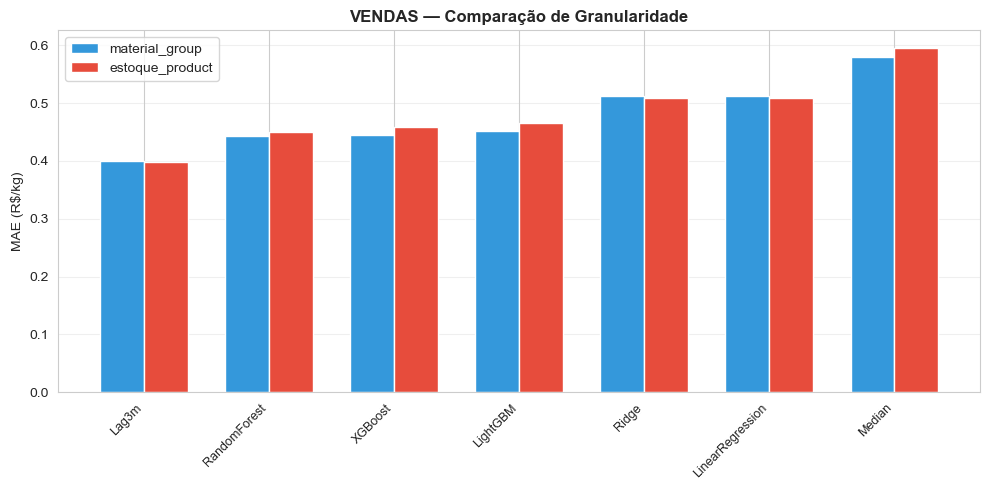


  MAE por Tier de Qualidade — Pipeline por Material

Distribuição dos tiers (material level):


quality
A (excellent)       579
B (good)            603
C (fair)            333
D (insufficient)    117
Name: count, dtype: int64


  VENDAS — MAE por Tier (material level)


,quality_tier,n_obs,MAE_Median,MAE_Lag3m,MAE_LinearRegression,MAE_Ridge,MAE_RandomForest,MAE_XGBoost,MAE_LightGBM
0,A (excellent),579,0.6648,0.3616,0.4789,0.4787,0.4348,0.4465,0.4637
1,B (good),603,0.6814,0.4665,0.5693,0.5691,0.4845,0.4864,0.4939
2,C (fair),333,0.3826,0.3546,0.4665,0.4664,0.4299,0.4461,0.4399
3,D (insufficient),117,0.2605,0.3099,0.3958,0.3958,0.3682,0.3870,0.3711


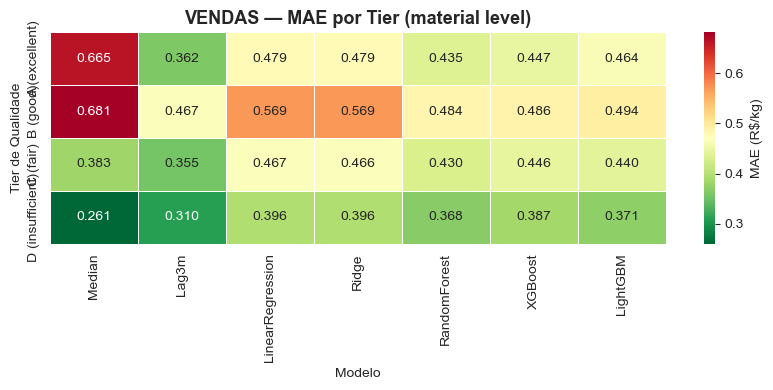

In [141]:
# === Material-level CV Results + Comparison with material_group pipeline ===

# --- Global summary: material level ---
print(f"{'='*65}")
print(f"  RESULTADOS — Pipeline por Material (estoque_product)")
print(f"{'='*65}")

all_results_mat = []
for (model_name, side_name), grp in df_cv_scores_mat.groupby(["model", "side"]):
    all_results_mat.append({
        "model": model_name,
        "side": side_name,
        "n_folds": len(grp),
        "n_total": grp["n"].sum(),
        "MAE_mean": round(grp["MAE"].mean(), 4),
        "MAE_std": round(grp["MAE"].std(), 4),
        "RMSE_mean": round(grp["RMSE"].mean(), 4),
        "R2_mean": round(grp["R2"].mean(), 4),
        "MAPE_%_mean": round(grp["MAPE_%"].mean(), 1),
    })

df_all_results_mat = pd.DataFrame(all_results_mat).sort_values(["side", "MAE_mean"])
display(df_all_results_mat)

best_models_mat = {}
side_df = df_all_results_mat[df_all_results_mat["side"] == "VENDAS"]
if not side_df.empty:
    best_row = side_df.iloc[0]
    best_models_mat["VENDAS"] = best_row["model"]
    print(f"\nMelhor modelo VENDAS (material): {best_row['model']} — MAE={best_row['MAE_mean']:.4f} ± {best_row['MAE_std']:.4f}")

# --- Side-by-side comparison ---
print(f"\n{'='*65}")
print(f"  COMPARAÇÃO: material_group vs estoque_product")
print(f"{'='*65}")

comparison = []
side = "VENDAS"
grp_df = df_all_results[df_all_results["side"] == side]
mat_df = df_all_results_mat[df_all_results_mat["side"] == side]
for _, row_g in grp_df.iterrows():
    model = row_g["model"]
    row_m = mat_df[mat_df["model"] == model]
    mae_mat = row_m["MAE_mean"].values[0] if len(row_m) > 0 else np.nan
    comparison.append({
        "side": side,
        "model": model,
        "MAE_group": row_g["MAE_mean"],
        "MAE_material": mae_mat,
        "diff": round(mae_mat - row_g["MAE_mean"], 4) if not np.isnan(mae_mat) else np.nan,
        "better": "material" if not np.isnan(mae_mat) and mae_mat < row_g["MAE_mean"] else "group",
    })

df_comparison = pd.DataFrame(comparison).sort_values(["side", "MAE_group"])
display(df_comparison)

# --- Bar chart comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
comp = df_comparison.copy()
if not comp.empty:
    comp["model_short"] = comp["model"].str.replace(f" (VENDAS)", "", regex=False)
    x = np.arange(len(comp))
    w = 0.35
    ax.bar(x - w/2, comp["MAE_group"], w, label="material_group", color="#3498db", edgecolor="white")
    ax.bar(x + w/2, comp["MAE_material"], w, label="estoque_product", color="#e74c3c", edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels(comp["model_short"], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("MAE (R$/kg)")
    ax.set_title("VENDAS — Comparação de Granularidade", fontweight="bold")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# --- Quality tier breakdown for material-level pipeline ---
print(f"\n{'='*65}")
print(f"  MAE por Tier de Qualidade — Pipeline por Material")
print(f"{'='*65}")

test_mat_qt = test_mat.merge(
    coverage_mat[["estoque_product", "emitterstateuf", "quality"]],
    on=["estoque_product", "emitterstateuf"],
    how="left",
)
test_mat_qt["quality"] = test_mat_qt["quality"].fillna("D (insufficient)")

print(f"\nDistribuição dos tiers (material level):")
display(test_mat_qt["quality"].value_counts().sort_index())

pred_cols_mat = [c for c in test_mat_qt.columns if c.startswith("pred_")]
model_names_mat = [c.replace("pred_", "") for c in pred_cols_mat]

side = "VENDAS"
te = test_mat_qt[test_mat_qt["side"] == side].copy()
if len(te) > 0:
    print(f"\n  {side} — MAE por Tier (material level)")
    tier_metrics = []
    for tier, grp_df in te.groupby("quality"):
        row = {"quality_tier": tier, "n_obs": len(grp_df)}
        for mname in model_names_mat:
            col = f"pred_{mname}"
            if col in grp_df.columns:
                valid = grp_df.dropna(subset=[col])
                if len(valid) > 0:
                    row[f"MAE_{mname}"] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                else:
                    row[f"MAE_{mname}"] = np.nan
        tier_metrics.append(row)

    df_tier_mat = pd.DataFrame(tier_metrics).sort_values("quality_tier")
    display(df_tier_mat)

    mae_cols_t = [c for c in df_tier_mat.columns if c.startswith("MAE_")]
    if len(mae_cols_t) > 0 and len(df_tier_mat) >= 2:
        fig, ax = plt.subplots(figsize=(max(8, len(mae_cols_t) * 1.2), 4))
        hm_data = df_tier_mat.set_index("quality_tier")[mae_cols_t].rename(columns=lambda c: c.replace("MAE_", ""))
        sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=ax,
                    linewidths=0.5, cbar_kws={"label": "MAE (R$/kg)"})
        ax.set_title(f"{side} — MAE por Tier (material level)", fontsize=13, fontweight="bold")
        ax.set_ylabel("Tier de Qualidade")
        ax.set_xlabel("Modelo")
        plt.tight_layout()
        plt.show()

### 7b.1 Acurácia por Estado × Material (estoque_product)

Análise de pares **estado × produto específico** (estoque_product) para o pipeline por material — análogo à seção 6b mas com granularidade de produto.


  VENDAS — MAE por Estado (material pipeline, best: Lag3m)


,state,n_obs,MAE_Median,MAE_Lag3m,MAE_LinearRegression,MAE_Ridge,MAE_RandomForest,MAE_XGBoost,MAE_LightGBM
0,AL,4,0.0000,0.0000,0.2684,0.2682,0.0533,0.0443,0.0480
1,AM,6,0.0125,0.0354,0.1748,0.1748,0.2035,0.2022,0.2211
10,MT,1,0.0600,0.0600,0.3299,0.3297,0.0634,0.0883,0.0757
14,PI,2,0.0700,0.0700,0.3466,0.3464,0.2653,0.2492,0.3193
7,MA,50,0.1924,0.1117,0.2438,0.2437,0.1708,0.1798,0.1642
15,PR,254,0.4705,0.2247,0.3429,0.3429,0.2786,0.2910,0.2935
18,RS,256,0.5504,0.2921,0.3956,0.3954,0.3522,0.3476,0.3478
4,DF,48,0.4503,0.3472,0.4582,0.4579,0.4945,0.4966,0.4605
21,SP,235,0.5729,0.3726,0.4706,0.4704,0.4389,0.4469,0.4617
8,MG,179,0.4385,0.3869,0.4972,0.4971,0.4882,0.4980,0.5058


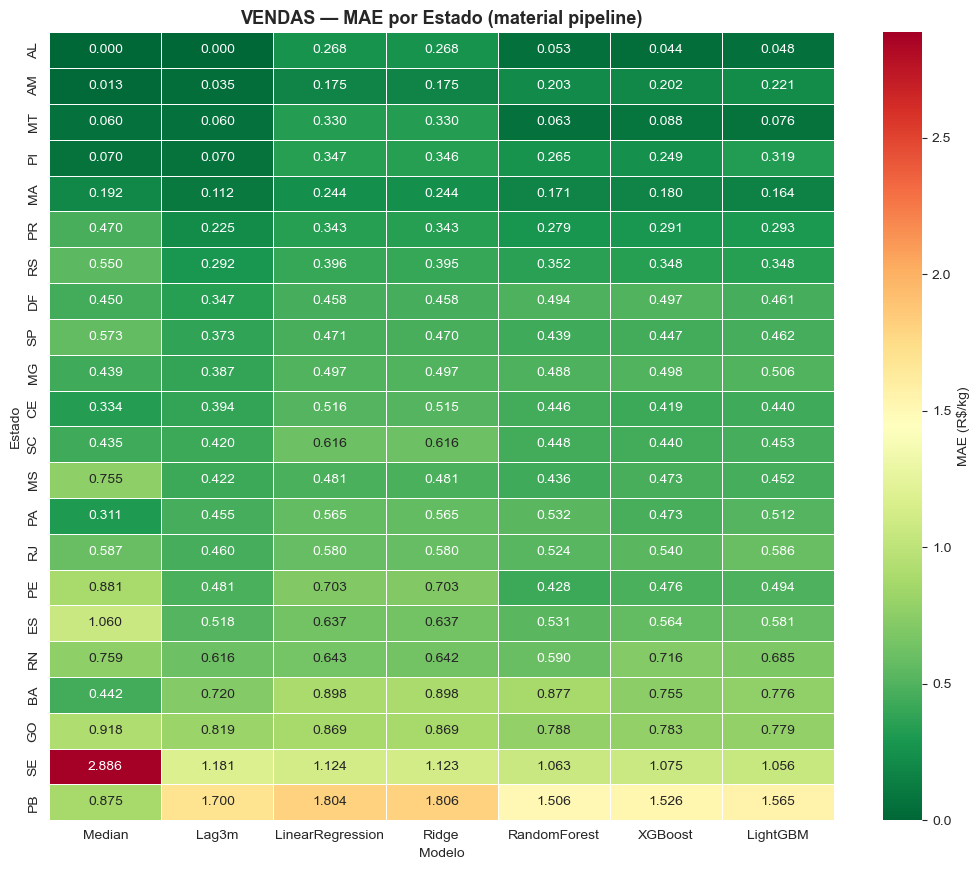


  VENDAS — MAE por Estado × Produto (best: Lag3m)

  Total de pares estado×produto: 227


,state,estoque_product,n_obs,MAE_Lag3m,MAE_Median
0,AL,SUCATA DE PLASTICO,4,0.0000,0.0000
29,ES,PEAD CRISTAL,8,0.0000,0.0000
170,RS,PP PRETO,2,0.0000,0.0000
151,RN,PET OLEO,1,0.0000,NaN
41,ES,SUCATA DE PET BANDEJA,4,0.0000,0.0000
...,...,...,...,...,...
55,GO,SUCATA DE PEAD COLORIDO,1,2.1300,2.1300
193,SC,SUCATA DE PEAD COLORIDO,2,2.8000,2.8000
25,DF,SUCATA DE LATINHAS,1,3.4057,5.0000
4,BA,PET CRISTAL,3,3.6667,0.7437


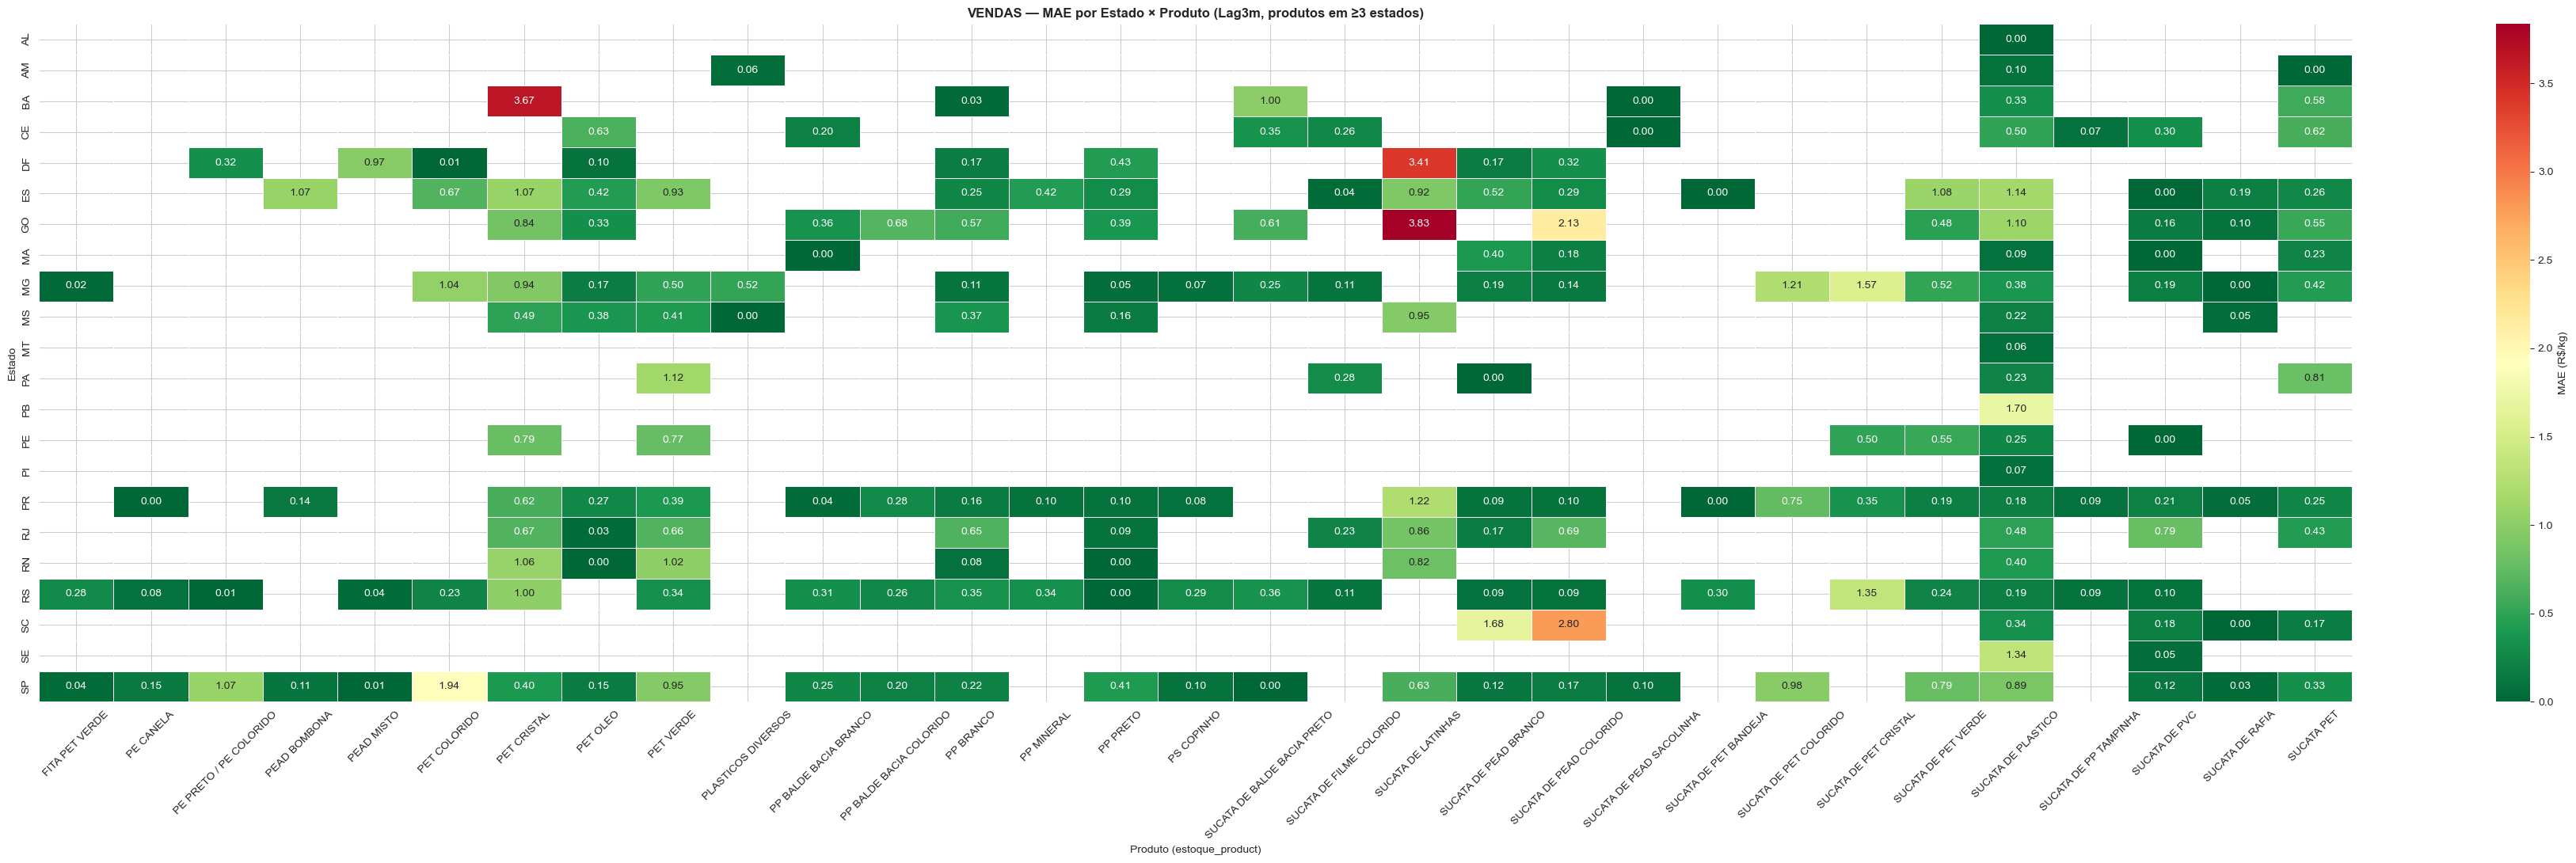


  Top 10 pares com MENOR MAE (Lag3m):


,state,estoque_product,n_obs,MAE_Lag3m
0,AL,SUCATA DE PLASTICO,4,0.0
29,ES,PEAD CRISTAL,8,0.0
170,RS,PP PRETO,2,0.0
151,RN,PET OLEO,1,0.0
41,ES,SUCATA DE PET BANDEJA,4,0.0
44,ES,SUCATA DE PVC,1,0.0
134,PR,SUCATA DE PS COPINHO,1,0.0
112,PR,PE CANELA,9,0.0
61,MA,PP BALDE BACIA BRANCO,10,0.0
110,PE,SUCATA DE PVC,6,0.0



  Top 10 pares com MAIOR MAE (Lag3m):


,state,estoque_product,n_obs,MAE_Lag3m
82,MG,SUCATA DE PET CRISTAL,6,1.5667
192,SC,SUCATA DE PEAD BRANCO,2,1.6750
104,PB,SUCATA DE PLASTICO,4,1.7000
191,RS,SUCATA PET CRISTAL E VERDE,1,1.8739
205,SP,PET COLORIDO,6,1.9417
55,GO,SUCATA DE PEAD COLORIDO,1,2.1300
193,SC,SUCATA DE PEAD COLORIDO,2,2.8000
25,DF,SUCATA DE LATINHAS,1,3.4057
4,BA,PET CRISTAL,3,3.6667
54,GO,SUCATA DE LATINHAS,6,3.8342


In [142]:
# === Accuracy breakdown by State × estoque_product (material-level pipeline) ===

pred_cols_pair = [c for c in test_mat.columns if c.startswith("pred_")]
model_names_pair = [c.replace("pred_", "") for c in pred_cols_pair]

side = "VENDAS"
te = test_mat[test_mat["side"] == side].copy()

best_model_name = best_models_mat.get(side)
if best_model_name is not None and len(te) > 0:
    best_short = best_model_name.replace(f" ({side})", "")
    best_pred_col = f"pred_{best_short}"

    if best_pred_col in te.columns:
        # ---------------------------------------------------------------
        # 1) MAE by STATE (material-level pipeline)
        # ---------------------------------------------------------------
        print(f"\n{'='*65}")
        print(f"  {side} — MAE por Estado (material pipeline, best: {best_short})")
        print(f"{'='*65}")

        state_metrics = []
        for state, grp_df in te.groupby("emitterstateuf"):
            row = {"state": state, "n_obs": len(grp_df)}
            for mname in model_names_pair:
                col = f"pred_{mname}"
                if col in grp_df.columns:
                    valid = grp_df.dropna(subset=[col])
                    if len(valid) > 0:
                        row[f"MAE_{mname}"] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                    else:
                        row[f"MAE_{mname}"] = np.nan
            state_metrics.append(row)

        df_state_mat = pd.DataFrame(state_metrics).sort_values(f"MAE_{best_short}")
        display(df_state_mat)

        mae_cols_s = [c for c in df_state_mat.columns if c.startswith("MAE_")]
        if len(mae_cols_s) > 0 and len(df_state_mat) >= 3:
            fig, ax = plt.subplots(figsize=(max(8, len(mae_cols_s) * 1.5), max(5, len(df_state_mat) * 0.4)))
            hm_data = df_state_mat.set_index("state")[mae_cols_s].rename(columns=lambda c: c.replace("MAE_", ""))
            sns.heatmap(hm_data, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=ax,
                        linewidths=0.5, cbar_kws={"label": "MAE (R$/kg)"})
            ax.set_title(f"{side} — MAE por Estado (material pipeline)", fontsize=13, fontweight="bold")
            ax.set_ylabel("Estado")
            ax.set_xlabel("Modelo")
            plt.tight_layout()
            plt.show()

        # ---------------------------------------------------------------
        # 2) MAE by STATE × ESTOQUE_PRODUCT
        # ---------------------------------------------------------------
        print(f"\n{'='*65}")
        print(f"  {side} — MAE por Estado × Produto (best: {best_short})")
        print(f"{'='*65}")

        pair_metrics_mat = []
        for (state, product), grp_df in te.groupby(["emitterstateuf", "estoque_product"]):
            row = {"state": state, "estoque_product": product, "n_obs": len(grp_df)}
            for mname in [best_short, "Lag3m", "Median"]:
                col = f"pred_{mname}"
                if col in grp_df.columns:
                    valid = grp_df.dropna(subset=[col])
                    if len(valid) > 0:
                        row[f"MAE_{mname}"] = round(mean_absolute_error(valid[TARGET], valid[col]), 4)
                    else:
                        row[f"MAE_{mname}"] = np.nan
            pair_metrics_mat.append(row)

        df_pairs_mat = pd.DataFrame(pair_metrics_mat).sort_values(f"MAE_{best_short}")
        print(f"\n  Total de pares estado×produto: {len(df_pairs_mat)}")
        display(df_pairs_mat)

        # --- Heatmap: top products with enough data ---
        prod_state_counts = df_pairs_mat.groupby("estoque_product")["state"].nunique()
        top_products = prod_state_counts[prod_state_counts >= 3].index.tolist()

        if top_products:
            pivot_mat = df_pairs_mat[df_pairs_mat["estoque_product"].isin(top_products)].pivot(
                index="state", columns="estoque_product", values=f"MAE_{best_short}"
            )
            if not pivot_mat.empty:
                fig, ax = plt.subplots(figsize=(max(12, len(pivot_mat.columns) * 1.2), max(4, len(pivot_mat) * 0.5)))
                sns.heatmap(pivot_mat, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax,
                            linewidths=0.5, cbar_kws={"label": "MAE (R$/kg)"})
                ax.set_title(f"{side} — MAE por Estado × Produto ({best_short}, produtos em ≥3 estados)",
                             fontsize=12, fontweight="bold")
                ax.set_ylabel("Estado")
                ax.set_xlabel("Produto (estoque_product)")
                ax.tick_params(axis="x", rotation=45)
                plt.tight_layout()
                plt.show()

        # --- Top 10 best and worst pairs ---
        valid_pairs_mat = df_pairs_mat.dropna(subset=[f"MAE_{best_short}"])
        if len(valid_pairs_mat) >= 5:
            print(f"\n  Top 10 pares com MENOR MAE ({best_short}):")
            display(valid_pairs_mat.head(10)[["state", "estoque_product", "n_obs", f"MAE_{best_short}"]])
            print(f"\n  Top 10 pares com MAIOR MAE ({best_short}):")
            display(valid_pairs_mat.tail(10)[["state", "estoque_product", "n_obs", f"MAE_{best_short}"]])

## 8. Tabela de Preço Justo

Combinação da referência estatística (mediana) com a previsão do melhor modelo para gerar uma tabela final de preço justo por grupo × estado.


  TABELA DE PREÇO JUSTO (R$/kg) — VENDAS (price_tier)

--- VENDAS (168 pares cluster×estado) ---

Quality distribution:


quality
A (excellent)       22
B (good)            35
C (fair)            63
D (insufficient)    48
Name: count, dtype: int64

,side,cluster,material_base,state,n_obs,median_price,Q1,Q3,fair_buy,fair_sell,fair_target,heterogeneity,n_products,n_months_data,top_products,quality
0,VENDAS,BOPP/RAFIA,BOPP/RAFIA,MG,17,0.200,0.200,0.200,0.200,0.200,0.200,0.060,1,13,SUCATA DE RAFIA,D (insufficient)
1,VENDAS,BOPP/RAFIA,BOPP/RAFIA,PR,185,0.300,0.200,0.400,0.200,0.400,0.300,0.337,2,36,"PP RAFIA, SUCATA DE RAFIA",B (good)
2,VENDAS,BOPP/RAFIA,BOPP/RAFIA,RS,14,0.110,0.062,0.188,0.062,0.188,0.110,0.576,2,9,"SUCATA DE RAFIA, PP RAFIA",D (insufficient)
3,VENDAS,BOPP/RAFIA,BOPP/RAFIA,SC,136,0.650,0.500,0.650,0.500,0.650,0.650,0.130,1,32,SUCATA DE RAFIA,A (excellent)
4,VENDAS,BOPP/RAFIA,BOPP/RAFIA,SP,65,0.300,0.100,0.300,0.100,0.300,0.300,0.479,1,25,SUCATA DE RAFIA,B (good)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,VENDAS,PVC,PVC,PR,190,0.575,0.450,0.900,0.450,0.900,0.575,0.490,1,36,SUCATA DE PVC,B (good)
164,VENDAS,PVC,PVC,RJ,7,0.200,0.125,1.100,0.125,1.100,0.200,1.198,1,7,SUCATA DE PVC,D (insufficient)
165,VENDAS,PVC,PVC,RS,36,0.400,0.300,0.750,0.300,0.750,0.400,0.532,1,19,SUCATA DE PVC,C (fair)
166,VENDAS,PVC,PVC,SC,18,0.600,0.425,1.000,0.425,1.000,0.600,0.563,1,12,SUCATA DE PVC,D (insufficient)


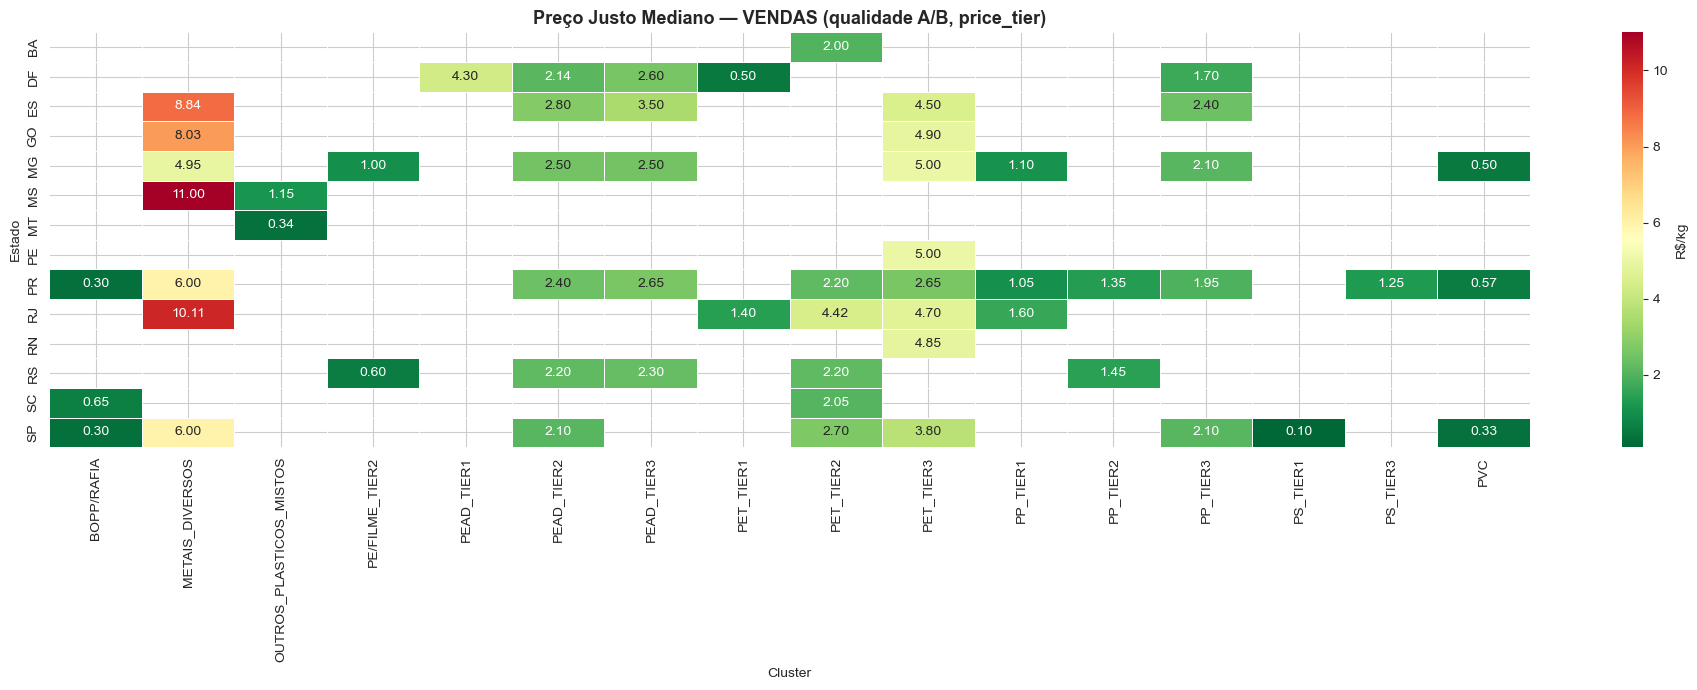


Exported to fair_prices_by_tier.csv (168 rows)


In [143]:
# === Fair price table: Tier-Specific (Phase 7) ===

fair_prices = []

side = "VENDAS"
side_data = df_price_clean[df_price_clean["natop_category"].isin(venda_cats)]

for (cluster, state), sub in side_data.groupby([best_cluster_col, "emitterstateuf"]):
    if len(sub) < 5:
        continue

    q1, median, q3 = sub[price_col].quantile([0.25, 0.5, 0.75])

    fair_prices.append({
        "side": side,
        "cluster": cluster,
        "material_base": sub["material_group"].iloc[0],
        "state": state,
        "n_obs": len(sub),
        "median_price": round(median, 3),
        "Q1": round(q1, 3),
        "Q3": round(q3, 3),
        "fair_buy": round(q1, 3),       # Buy at Q1 (conservative)
        "fair_sell": round(q3, 3),      # Sell at Q3 (optimistic)
        "fair_target": round(median, 3), # Target median
        "heterogeneity": round(sub[price_col].std() / sub[price_col].mean(), 3) if sub[price_col].mean() > 0 else 0,
        "n_products": sub["estoque_product"].nunique(),
        "n_months_data": sub["year_month"].nunique(),
        "top_products": ", ".join(sub["estoque_product"].value_counts().head(3).index.tolist()),
    })

df_fair = pd.DataFrame(fair_prices)

# Advanced quality tiers based on volume + heterogeneity
def quality_tier_advanced(row):
    if row["n_obs"] >= 100 and row["heterogeneity"] < 0.3:
        return "A (excellent)"
    elif row["n_obs"] >= 50 and row["heterogeneity"] < 0.5:
        return "B (good)"
    elif row["n_obs"] >= 20:
        return "C (fair)"
    else:
        return "D (insufficient)"

df_fair["quality"] = df_fair.apply(quality_tier_advanced, axis=1)

print(f"\n{'='*70}")
print(f"  TABELA DE PREÇO JUSTO (R$/kg) — VENDAS ({best_cluster_col})")
print(f"{'='*70}")
print(f"\n--- VENDAS ({len(df_fair)} pares cluster×estado) ---")
print(f"\nQuality distribution:")
display(df_fair["quality"].value_counts().sort_index())
display(df_fair.sort_values(["material_base", "cluster", "state"]))

# Heatmap: fair price range (A/B quality only)
side_df_ab = df_fair[df_fair["quality"].isin(["A (excellent)", "B (good)"])]
if not side_df_ab.empty:
    cluster_vals = sorted(side_df_ab["cluster"].unique())
    pivot = side_df_ab.pivot_table(index="state", columns="cluster", values="median_price", aggfunc="mean")
    if not pivot.empty:
        fig, ax = plt.subplots(figsize=(max(12, len(pivot.columns) * 1.2), max(4, len(pivot) * 0.5)))
        sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn_r", ax=ax,
                    linewidths=0.5, cbar_kws={"label": "R$/kg"})
        ax.set_title(f"Preço Justo Mediano — VENDAS (qualidade A/B, {best_cluster_col})",
                     fontsize=13, fontweight="bold")
        ax.set_ylabel("Estado")
        ax.set_xlabel("Cluster")
        plt.tight_layout()
        plt.show()

# Export for business use
df_fair.to_csv("fair_prices_by_tier.csv", index=False)
print(f"\nExported to fair_prices_by_tier.csv ({len(df_fair)} rows)")

## 9. Previsão vs Real (2025)

Visualização do preço previsto pelo melhor modelo vs preço real observado no ano de teste (2025).

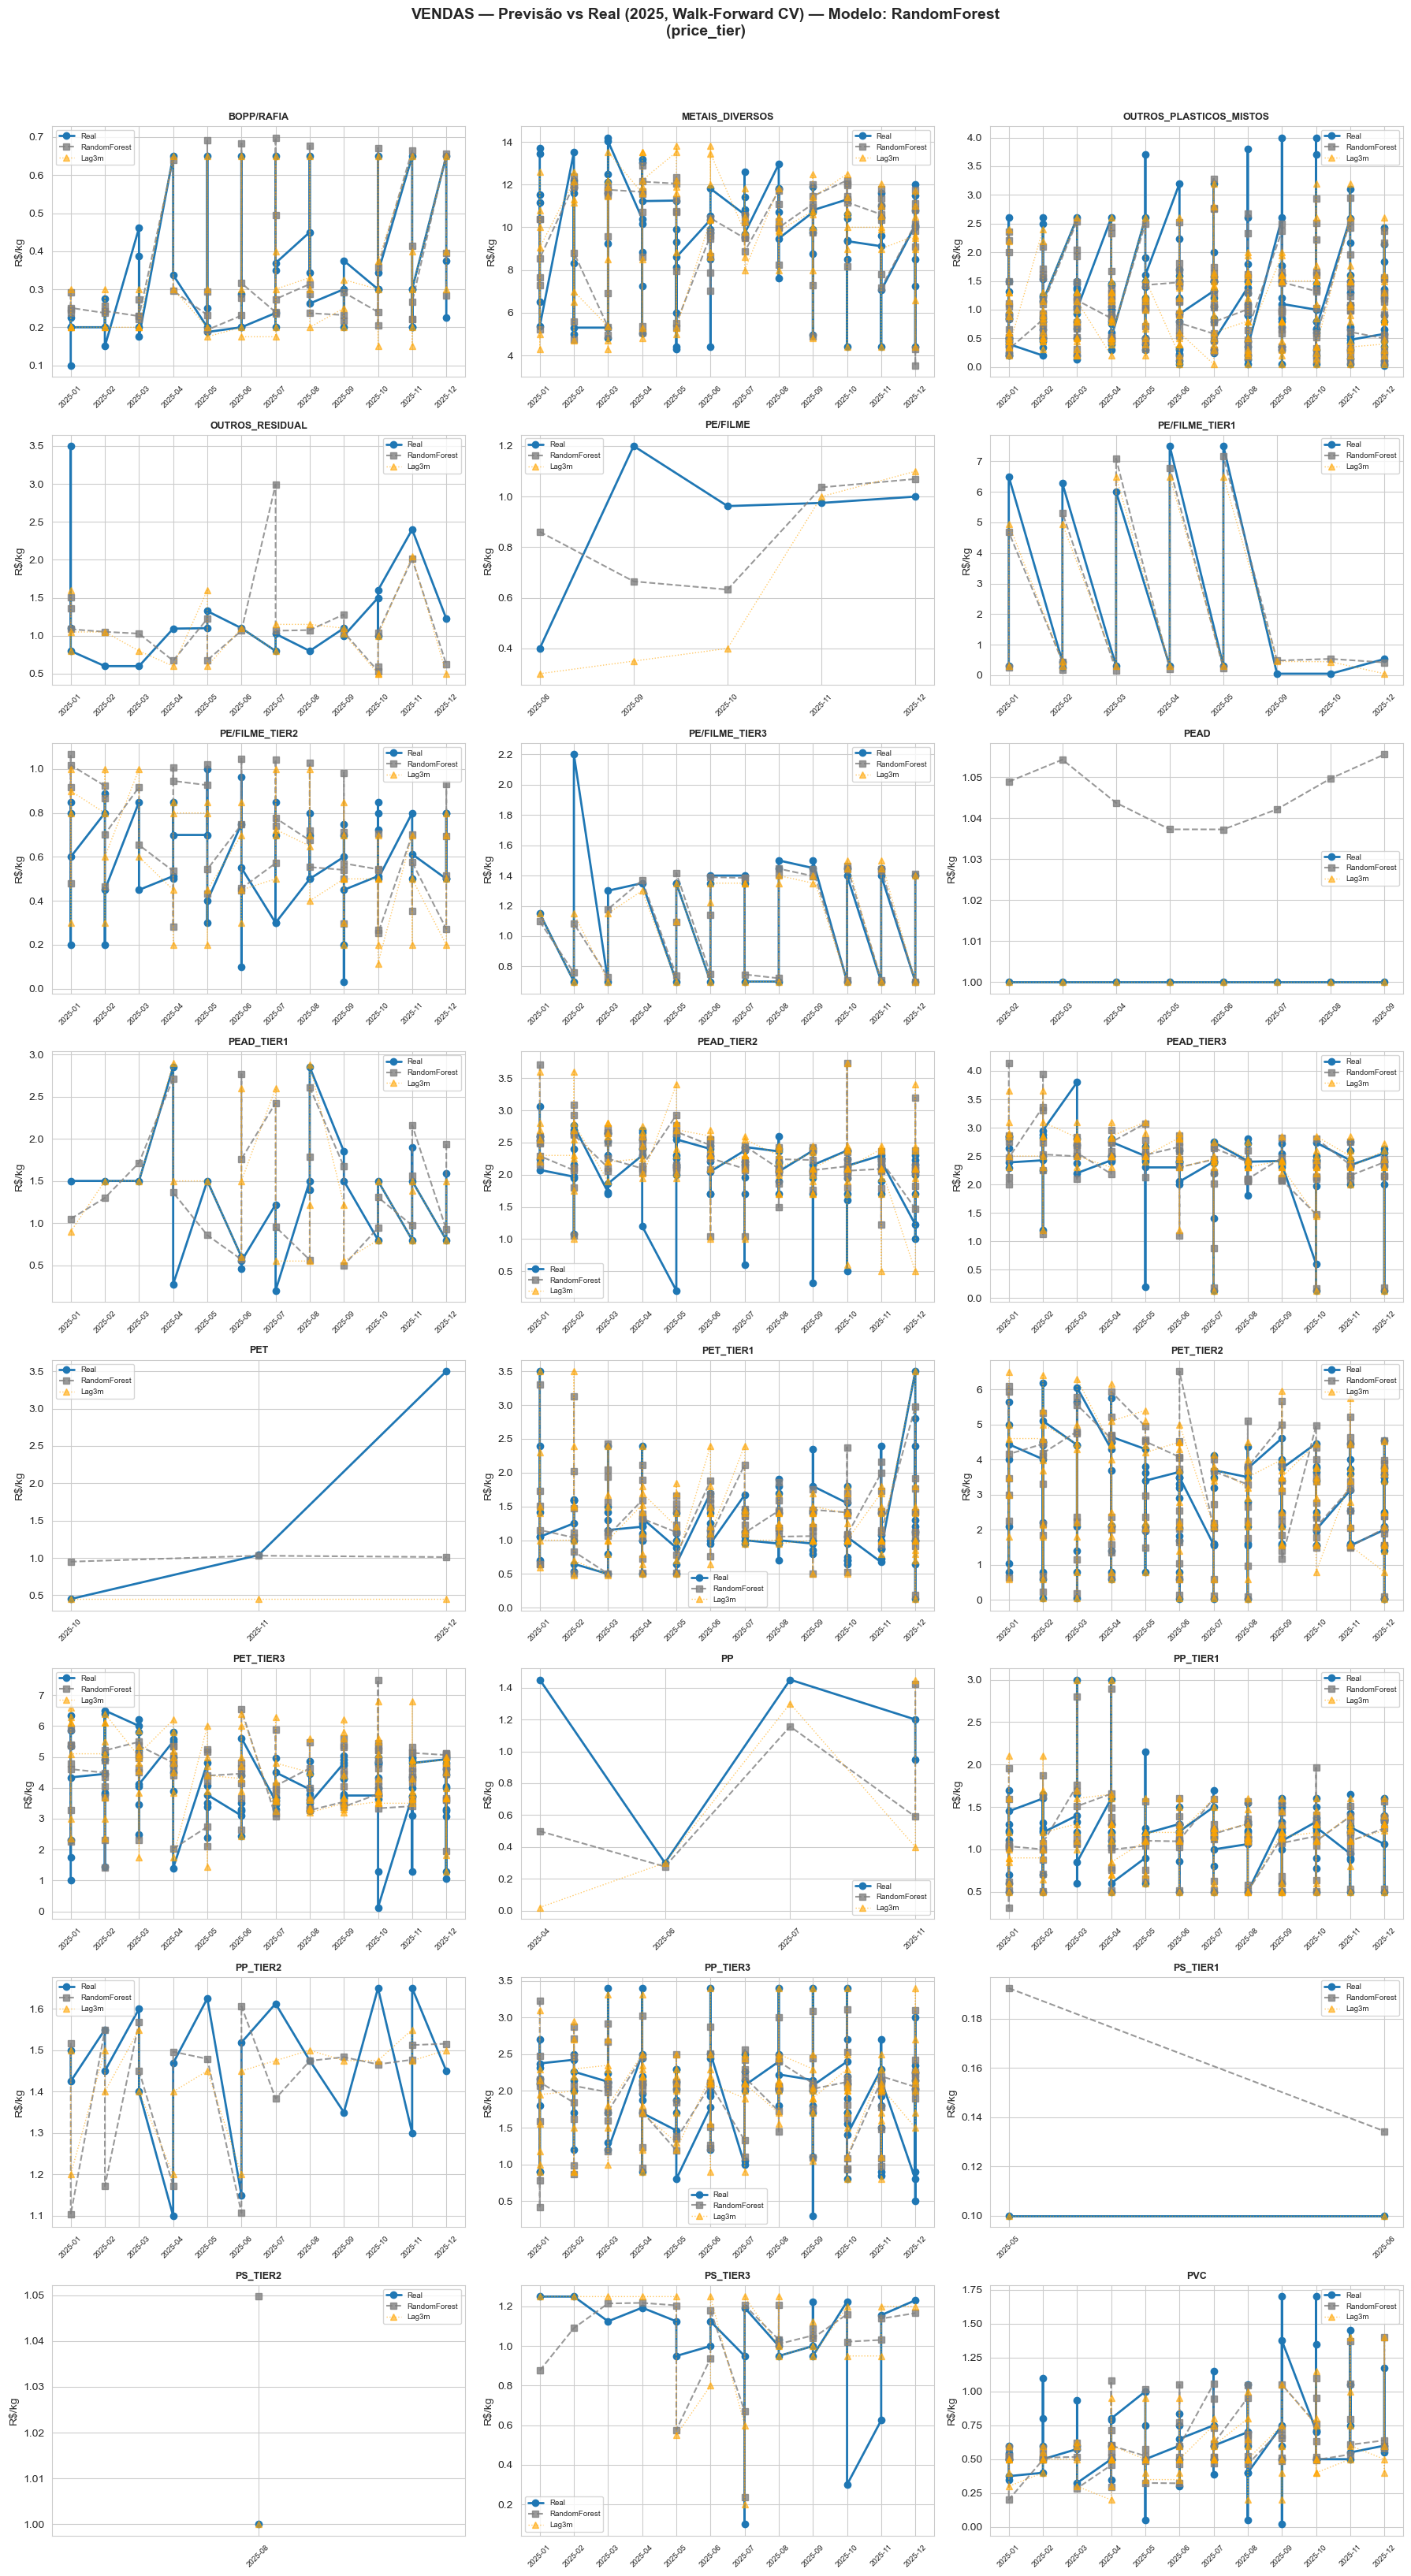

In [144]:
# === Predicted vs Actual: best model, by cluster ===

ml_pred_cols = [c for c in test.columns if c.startswith("pred_") and c not in ("pred_Median", "pred_Lag3m")]

side = "VENDAS"
te = test[test["side"] == side].copy()

if len(te) > 0:
    # Pick best ML pred column (lowest MAE)
    best_col = None
    best_mae = np.inf
    for col in ml_pred_cols:
        valid = te.dropna(subset=[col])
        if len(valid) > 0:
            mae = mean_absolute_error(valid[TARGET], valid[col])
            if mae < best_mae:
                best_mae = mae
                best_col = col

    if best_col is None:
        best_col = "pred_Lag3m"

    model_label = best_col.replace("pred_", "")

    side_groups = sorted(te[group_key].unique())
    if side_groups:
        n = len(side_groups)
        ncols = min(3, n)
        nrows = (n + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
        axes_flat = np.array(axes).flatten() if n > 1 else [axes]

        for idx, grp in enumerate(side_groups):
            ax = axes_flat[idx]
            grp_data = te[te[group_key] == grp].sort_values("date")
            if len(grp_data) == 0:
                ax.axis("off")
                continue

            x_labels = grp_data["date"].dt.strftime("%Y-%m")
            ax.plot(x_labels, grp_data[TARGET], "o-", label="Real", linewidth=2)
            ax.plot(x_labels, grp_data[best_col], "s--", label=model_label, color="gray", linewidth=1.5, alpha=0.8)
            ax.plot(x_labels, grp_data["pred_Lag3m"], "^:", label="Lag3m", color="orange", linewidth=1, alpha=0.6)
            ax.set_title(grp[:25], fontweight="bold", fontsize=9)
            ax.set_ylabel("R$/kg")
            ax.legend(fontsize=7)
            ax.tick_params(axis="x", rotation=45, labelsize=7)

        for idx in range(len(side_groups), len(axes_flat)):
            axes_flat[idx].axis("off")

        plt.suptitle(f"VENDAS — Previsão vs Real (2025, Walk-Forward CV) — Modelo: {model_label}\n({group_key})",
                     fontsize=14, fontweight="bold", y=1.02)
        plt.tight_layout()
        plt.show()

## 10. Resumo Final

Síntese dos resultados e próximos passos.

In [145]:
# === Final summary ===

print("=" * 60)
print("  RESUMO FINAL — Advanced Clustering Pipeline")
print("=" * 60)

print(f"\nDados utilizados:")
print(f"  Notas com match >0.6: {len(df_matched):,}")
print(f"  Com preço válido: {len(df_price):,}")
print(f"  Após remoção de outliers (VENDAS apenas): {len(df_price_clean):,}")

print(f"\nClusterização:")
print(f"  Estratégia selecionada: {best_strategy} ({best_cluster_col})")
print(f"  Clusters únicos: {df_price_clean[best_cluster_col].nunique()}")
if 'optimizer' in dir() and hasattr(optimizer, 'results_df') and len(optimizer.results_df) > 0:
    best_opt = optimizer.results_df.iloc[0]
    print(f"  Weighted MAE (otimizador): {best_opt['weighted_mae']:.4f}")
    print(f"  Weighted CV (otimizador):  {best_opt['weighted_cv']:.4f}")

print(f"\nValidação cruzada temporal (expanding window):")
print(f"  Folds: {len(months_2025)} (1 mês por fold)")
print(f"  Features: {len(FEATURES)}")
print(f"  Target: {TARGET}")
print(f"  Features externas: USD/BRL (PTAX), IPCA, sazonalidade regional")
print(f"  Features de heterogeneidade: n_products, price_spread, concentration")

print(f"\nModelos treinados por fold:")
model_names = list(dict.fromkeys(m for (_, m) in trained_models.keys()))
for name in model_names:
    print(f"  • {name}")

print(f"\n--- Melhor Modelo (menor MAE médio no walk-forward CV) ---")
for side, model_name in best_models.items():
    row = df_all_results[(df_all_results["model"] == model_name) & (df_all_results["side"] == side)].iloc[0]
    print(f"  {side}: {model_name} — MAE={row['MAE_mean']:.4f} ± {row['MAE_std']:.4f}")

print(f"\nTabela de preço justo ({best_cluster_col}):")
s = df_fair[df_fair["side"] == "VENDAS"]
print(f"  VENDAS: {len(s)} pares (cluster×estado)")
for q in sorted(s["quality"].unique()):
    n = len(s[s["quality"] == q])
    if n > 0:
        print(f"    {q}: {n} pares")

print(f"\nArquivos exportados:")
print(f"  fair_prices_by_tier.csv")

print(f"\nPróximos passos sugeridos:")
print(f"  1. Validar preços-referência com especialistas do negócio")
print(f"  2. Retreinar modelos com dados mais recentes à medida que novas notas chegam")
print(f"  3. Implementar monitoramento de drift nos preços")
print(f"  4. Avaliar clusters sinalizados para splitting adicional")
print(f"  5. Considerar pipeline material-level para clusters de alta granularidade")

  RESUMO FINAL — Advanced Clustering Pipeline

Dados utilizados:
  Notas com match >0.6: 21,269
  Com preço válido: 21,185
  Após remoção de outliers (VENDAS apenas): 20,078

Clusterização:
  Estratégia selecionada: price_tiers_3 (price_tier)
  Clusters únicos: 24
  Weighted MAE (otimizador): 1.0357
  Weighted CV (otimizador):  0.4733

Validação cruzada temporal (expanding window):
  Folds: 12 (1 mês por fold)
  Features: 11
  Target: price_fair
  Features externas: USD/BRL (PTAX), IPCA, sazonalidade regional
  Features de heterogeneidade: n_products, price_spread, concentration

Modelos treinados por fold:
  • LinearRegression
  • Ridge
  • RandomForest
  • XGBoost
  • LightGBM

--- Melhor Modelo (menor MAE médio no walk-forward CV) ---
  VENDAS: Lag3m (VENDAS) — MAE=0.3993 ± 0.1278

Tabela de preço justo (price_tier):
  VENDAS: 168 pares (cluster×estado)
    A (excellent): 22 pares
    B (good): 35 pares
    C (fair): 63 pares
    D (insufficient): 48 pares

Arquivos exportados:
  fa

In [125]:
# === Run this after your data cleaning (df_price_clean) ===

# 1. Identify high-frequency group-state pairs
group_state_stats = df_price_clean.groupby(["material_group", "emitterstateuf"]).agg(
    total_transactions=("unitpricekg_product", "count"),
    n_unique_products=("estoque_product", "nunique"),
    price_mean=("unitpricekg_product", "mean"),
    price_std=("unitpricekg_product", "std"),
    price_cv=("unitpricekg_product", lambda x: x.std() / x.mean()),
    q10=("unitpricekg_product", lambda x: x.quantile(0.1)),
    q90=("unitpricekg_product", lambda x: x.quantile(0.9)),
).reset_index()

# Calculate price spread (q90 - q10) as proxy for mixing different quality tiers
group_state_stats["price_spread"] = group_state_stats["q90"] - group_state_stats["q10"]

# High occurrence + high variance = problematic mixing
problematic = group_state_stats[
    (group_state_stats["total_transactions"] > 100) &  # High occurrence
    (group_state_stats["price_cv"] > 0.3)               # High variance (30%+ CV)
].sort_values("price_cv", ascending=False)

print("Top 10 Mixed-Profile Groups (High volume, High price variance):")
display(problematic.head(10))

Top 10 Mixed-Profile Groups (High volume, High price variance):


,material_group,emitterstateuf,total_transactions,n_unique_products,price_mean,price_std,price_cv,q10,q90,price_spread
34,OUTROS,SP,616,4,2.697968,3.115890,1.154902,0.05,8.00,7.95
20,OUTROS,MG,829,4,1.488771,1.356357,0.911059,0.12,3.70,3.58
21,OUTROS,MS,268,5,5.504142,4.975942,0.904036,0.45,12.20,11.75
18,OUTROS,GO,468,3,6.195470,4.942693,0.797791,0.10,13.86,13.76
61,PEAD,SP,963,5,1.512015,1.153556,0.762926,0.02,2.80,2.78
31,OUTROS,RS,259,3,0.681173,0.517226,0.759317,0.20,1.38,1.18
63,PET,BA,164,6,3.440488,2.453007,0.712982,1.10,6.80,5.70
15,OUTROS,CE,106,2,1.326769,0.917168,0.691279,0.03,2.70,2.67
69,PET,MG,749,10,3.002443,2.038763,0.679035,0.45,5.81,5.36
27,OUTROS,PR,234,2,4.745551,3.061509,0.645133,0.05,9.00,8.95


In [ ]:
def analyze_price_tiers(material, state, min_obs=10):
    """Analyze sub-product price distribution within a group-state"""
    subset = df_price_clean[
        (df_price_clean["material_group"] == material) &
        (df_price_clean["emitterstateuf"] == state)
    ]

    product_stats = subset.groupby("estoque_product")["unitpricekg_product"].agg([
        "count", "mean", "std", "median"
    ]).reset_index()
    product_stats = product_stats[product_stats["count"] >= min_obs]
    product_stats = product_stats.sort_values("mean", ascending=False)

    # Calculate gap between price tiers
    if len(product_stats) >= 2:
        product_stats["price_gap_vs_top"] = product_stats["mean"].iloc[0] - product_stats["mean"]
        product_stats["tier"] = pd.cut(
            product_stats["mean"],
            bins=3,
            labels=["Premium", "Standard", "Low-grade"]
        )

    return product_stats

# Example: Check the worst offender from the list above
# worst = problematic.iloc[0]
# analyze_price_tiers(worst["material_group"], worst["emitterstateuf"])

/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_34031/432723897.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=[p[:15] for p in top_products])
/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_34031/432723897.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=[p[:15] for p in top_products])
/var/folders/mq/jmjwxty97tjbkgg_0tjt9fm80000gn/T/ipykernel_34031/432723897.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(plot_data, labels=[p[:15] for p in top_products])


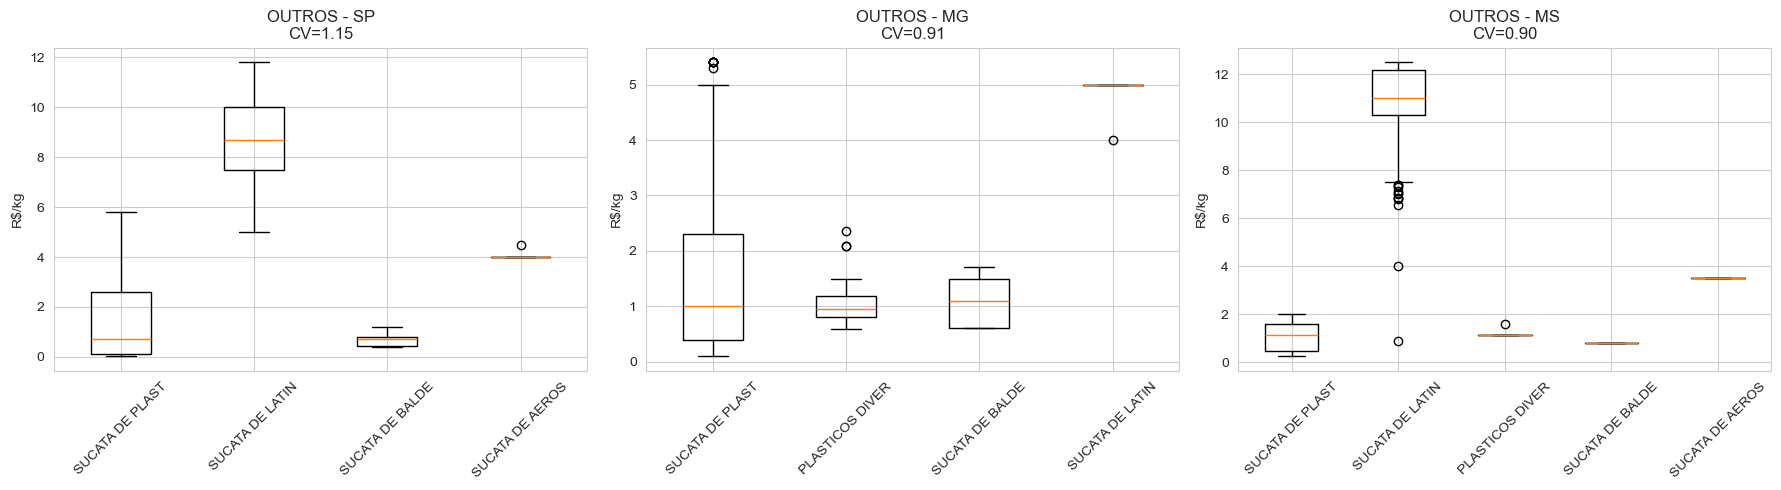

In [127]:
# Show price distributions for top 3 problematic groups
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
top3 = problematic.head(3)

for idx, row in enumerate(top3.itertuples()):
    ax = axes[idx]
    data = df_price_clean[
        (df_price_clean["material_group"] == row.material_group) &
        (df_price_clean["emitterstateuf"] == row.emitterstateuf)
    ]

    # Boxplot by sub-product (top 6 most frequent)
    top_products = data["estoque_product"].value_counts().head(6).index
    plot_data = [data[data["estoque_product"] == p]["unitpricekg_product"].values for p in top_products]

    ax.boxplot(plot_data, labels=[p[:15] for p in top_products])
    ax.set_title(f"{row.material_group} - {row.emitterstateuf}\nCV={row.price_cv:.2f}")
    ax.set_ylabel("R$/kg")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()